# Exploratory Data Analysis (EDA)
## Music Prediction Dataset - Phase 1

**Dataset:** 732,988 clean songs with audio features, lyrics, and metadata

**Target Variables:**
1. Valence (mood: sad → happy)
2. Energy (intensity)
3. Danceability
4. Popularity

**Goals:**
- Understand data distributions
- Identify correlations
- Detect patterns by genre/year
- Plan feature engineering strategy

In [2]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Academic publication style settings
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.5)
sns.set_palette("deep")

# Configure matplotlib for publication quality
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 17
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

print("✓ Libraries loaded successfully!")
print("✓ Academic publication style configured")

✓ Libraries loaded successfully!
✓ Academic publication style configured


## 1. Load Data

In [3]:
# Load cleaned dataset
data_path = Path('../data/processed/songs.csv')
print(f"Loading data from: {data_path}")

df = pd.read_csv(data_path)

print(f"\n✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loading data from: ../data/processed/songs.csv

✅ Dataset loaded successfully!
Shape: 550,622 rows × 24 columns


In [4]:
# First look at the data
df.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,"[""HELLYEAH""]",0.415,0.605,7,-11.157,1,0.0575,...,100.059,79500,"He said he came from Jamaica,\nhe owned a coup...",2016,Rock,0,769490,52.0,"[""4hxDvVq5t8ebPYPdBl1F9f""]","[""groove metal"", ""metal""]"
1,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,79.998,114000,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,"[""2jwRHcdgkRhelYEMqndDKe""]",[]
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.1490,...,175.317,197400,You like to stand on the other side\nPoint and...,2002,Rock,0,36619,35.0,"[""4YAN46l70QV0PGXlMg0iHi""]","[""melodic hardcore"", ""pop punk"", ""punk"", ""skat..."
3,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,142.959,178533,"It's been a while, shit, I missed the rehab, p...",2018,Hip-Hop,43,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,!Lost!,"[""Ril\u00e8s""]",0.729,0.552,7,-8.562,0,0.0650,...,86.103,186197,I would like to give you all my time\nI would ...,2018,Hip-Hop,0,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"


In [5]:
# Column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550622 entries, 0 to 550621
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      550622 non-null  object 
 1   name                    550619 non-null  object 
 2   album_name              550602 non-null  object 
 3   artists                 550622 non-null  object 
 4   danceability            550622 non-null  float64
 5   energy                  550622 non-null  float64
 6   key                     550622 non-null  int64  
 7   loudness                550622 non-null  float64
 8   mode                    550622 non-null  int64  
 9   speechiness             550622 non-null  float64
 10  acousticness            550622 non-null  float64
 11  instrumentalness        550622 non-null  float64
 12  liveness                550622 non-null  float64
 13  valence                 550622 non-null  float64
 14  tempo               

## 2. Basic Statistics

In [6]:
# Summary statistics for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe().round(3)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,year,popularity,total_artist_followers,avg_artist_popularity
count,550622.000,550622.000,550622.000,550622.000,550622.000,550622.000,550622.000,550622.000,550622.000,550622.000,550622.000,550622.000,550622.000,550622.000,5.506220e+05,550622.000
mean,0.527,0.671,5.275,-7.878,0.667,0.086,0.243,0.108,0.224,0.465,122.815,237411.630,2007.145,17.576,2.533411e+06,48.077
std,0.173,0.246,3.558,3.859,0.471,0.093,0.307,0.240,0.197,0.249,29.454,95552.726,13.576,17.458,9.227678e+06,19.154
min,0.046,0.000,0.000,-44.868,0.000,0.022,0.000,0.000,0.007,0.000,30.946,15027.000,1900.000,0.000,0.000000e+00,0.000
25%,0.408,0.496,2.000,-9.907,0.000,0.035,0.004,0.000,0.100,0.259,99.978,184040.000,2002.000,0.000,5.510225e+04,35.000
50%,0.530,0.716,5.000,-7.038,1.000,0.050,0.076,0.000,0.141,0.447,121.729,223000.000,2010.000,14.000,2.693830e+05,49.000
75%,0.651,0.886,8.000,-5.095,1.000,0.092,0.432,0.032,0.294,0.660,140.938,270783.000,2017.000,30.000,1.354562e+06,62.000
max,0.988,1.000,11.000,0.000,1.000,0.966,0.996,0.998,1.000,0.998,245.941,4995315.000,2025.000,98.000,2.951819e+08,100.000


In [7]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
}).sort_values('Missing', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing'] > 0])

Missing Values Summary:
            Missing  Percentage
album_name       20         0.0
name              3         0.0


## 3. Target Variables Analysis
### Our 4 targets: Valence, Energy, Danceability, Popularity

In [8]:
# Define target variables
target_vars = ['valence', 'energy', 'danceability', 'popularity']

# Check completeness
print("Target Variables Completeness:")
for target in target_vars:
    complete = df[target].notna().sum()
    pct = (complete / len(df) * 100)
    print(f"{target:15s}: {complete:,} / {len(df):,} ({pct:.2f}%)")

Target Variables Completeness:
valence        : 550,622 / 550,622 (100.00%)
energy         : 550,622 / 550,622 (100.00%)
danceability   : 550,622 / 550,622 (100.00%)
popularity     : 550,622 / 550,622 (100.00%)


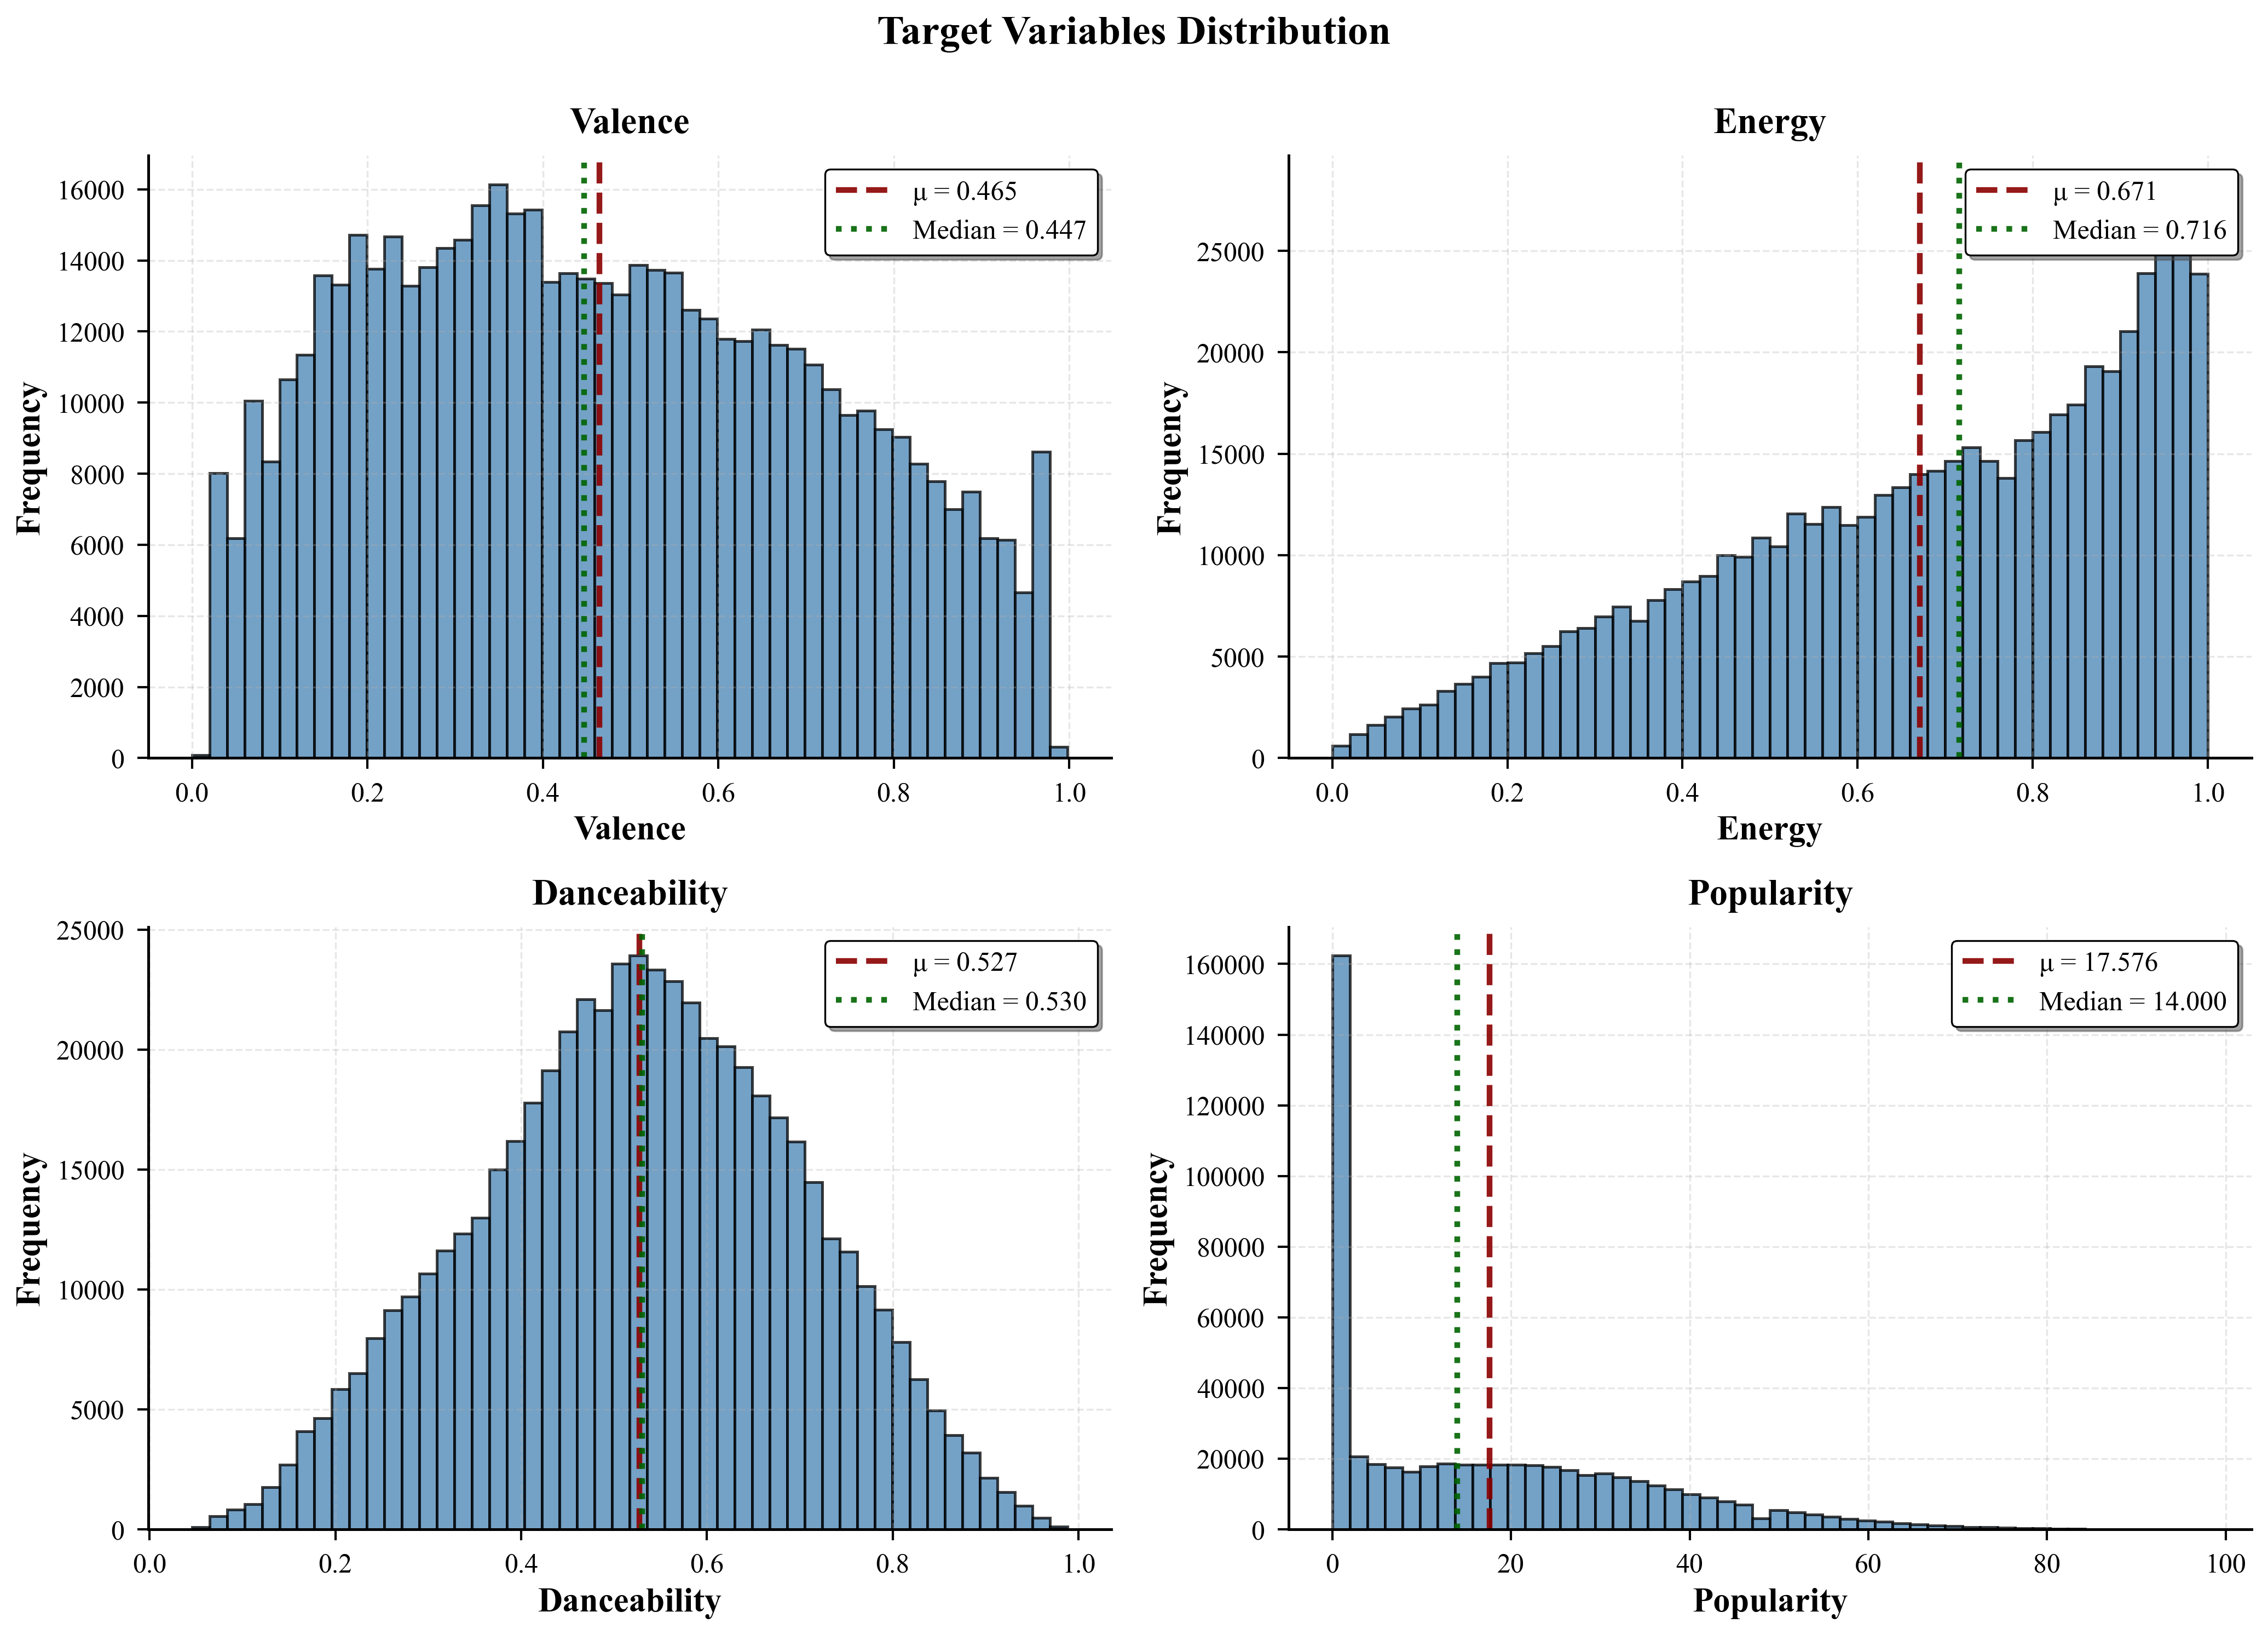


TABLE 1: Target Variables - Descriptive Statistics
                 count    mean     std    min     max   range
valence       550622.0   0.465   0.249  0.000   0.998   0.998
energy        550622.0   0.671   0.246  0.000   1.000   1.000
danceability  550622.0   0.527   0.173  0.046   0.988   0.942
popularity    550622.0  17.576  17.458  0.000  98.000  98.000


In [30]:
# Target variables distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Target Variables Distribution', fontsize=18, fontweight='bold', y=0.995)

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]
    
    # Histogram with academic styling
    n, bins, patches = ax.hist(df[target].dropna(), bins=50, edgecolor='black', 
                                alpha=0.75, color='steelblue', linewidth=1.2)
    
    # Statistical lines
    mean_val = df[target].mean()
    median_val = df[target].median()
    
    ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2.5, 
               label=f'μ = {mean_val:.3f}', alpha=0.9)
    ax.axvline(median_val, color='darkgreen', linestyle=':', linewidth=2.5, 
               label=f'Median = {median_val:.3f}', alpha=0.9)
    
    ax.set_xlabel(target.capitalize(), fontsize=15, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=15, fontweight='bold')
    ax.set_title(f'{target.capitalize()}', fontsize=16, fontweight='bold', pad=10)
    ax.legend(loc='upper right', frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()

# Create directory if it doesn't exist
from pathlib import Path
Path('../results/figures/eda').mkdir(parents=True, exist_ok=True)

plt.savefig('../results/figures/eda/target_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics table with formatting
print("\n" + "="*80)
print("TABLE 1: Target Variables - Descriptive Statistics")
print("="*80)
stats_df = df[target_vars].describe().T
stats_df['range'] = stats_df['max'] - stats_df['min']
stats_df = stats_df[['count', 'mean', 'std', 'min', 'max', 'range']]
print(stats_df.round(3).to_string())
print("="*80)

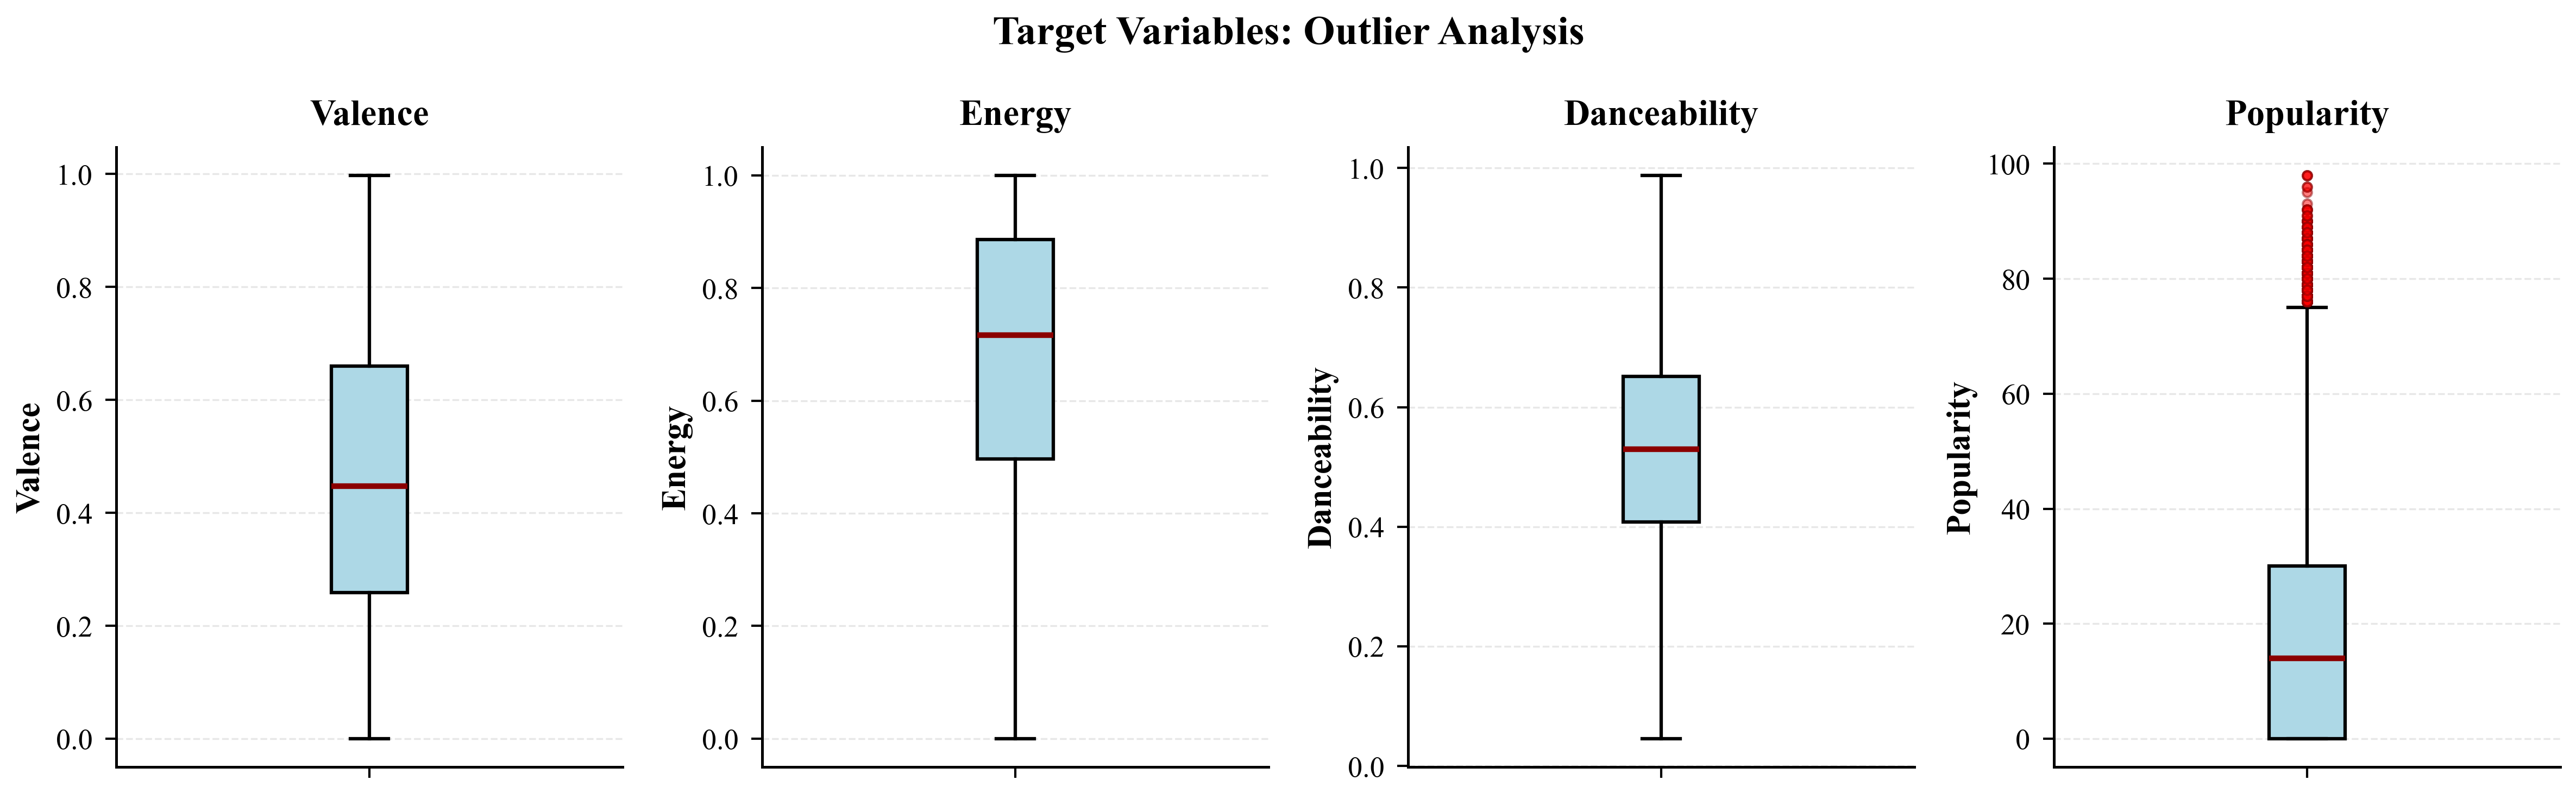

In [10]:
# Box plots for targets - Academic style
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Target Variables: Outlier Analysis', fontsize=18, fontweight='bold', y=0.98)

for idx, target in enumerate(target_vars):
    bp = axes[idx].boxplot(df[target].dropna(), vert=True, patch_artist=True,
                           boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                           medianprops=dict(color='darkred', linewidth=2.5),
                           whiskerprops=dict(color='black', linewidth=1.5),
                           capprops=dict(color='black', linewidth=1.5),
                           flierprops=dict(marker='o', markerfacecolor='red', markersize=4, 
                                          alpha=0.5, markeredgecolor='darkred'))
    
    axes[idx].set_ylabel(target.capitalize(), fontsize=15, fontweight='bold')
    axes[idx].set_title(f'{target.capitalize()}', fontsize=16, fontweight='bold', pad=10)
    axes[idx].grid(True, alpha=0.3, axis='y', linestyle='--')
    axes[idx].set_xticklabels([''])
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/figures/eda/target_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Audio Features Analysis
### Features that will be used for prediction

In [11]:
# Define audio features (including new artist features)
audio_features = [
    'acousticness', 'instrumentalness', 'liveness', 'speechiness',
    'loudness', 'tempo', 'duration_ms', 'key', 'mode'
]

# Artist features (new for Experiment 2)
artist_features = ['total_artist_followers', 'avg_artist_popularity']

print("Audio Features Summary:")
print(df[audio_features].describe().round(3))

print("\n✨ Artist Features Summary:")
print(df[artist_features].describe().round(3))

Audio Features Summary:
       acousticness  instrumentalness    liveness  speechiness    loudness  \
count    550622.000        550622.000  550622.000   550622.000  550622.000   
mean          0.243             0.108       0.224        0.086      -7.878   
std           0.307             0.240       0.197        0.093       3.859   
min           0.000             0.000       0.007        0.022     -44.868   
25%           0.004             0.000       0.100        0.035      -9.907   
50%           0.076             0.000       0.141        0.050      -7.038   
75%           0.432             0.032       0.294        0.092      -5.095   
max           0.996             0.998       1.000        0.966       0.000   

            tempo  duration_ms         key        mode  
count  550622.000   550622.000  550622.000  550622.000  
mean      122.815   237411.630       5.275       0.667  
std        29.454    95552.726       3.558       0.471  
min        30.946    15027.000       0.000   

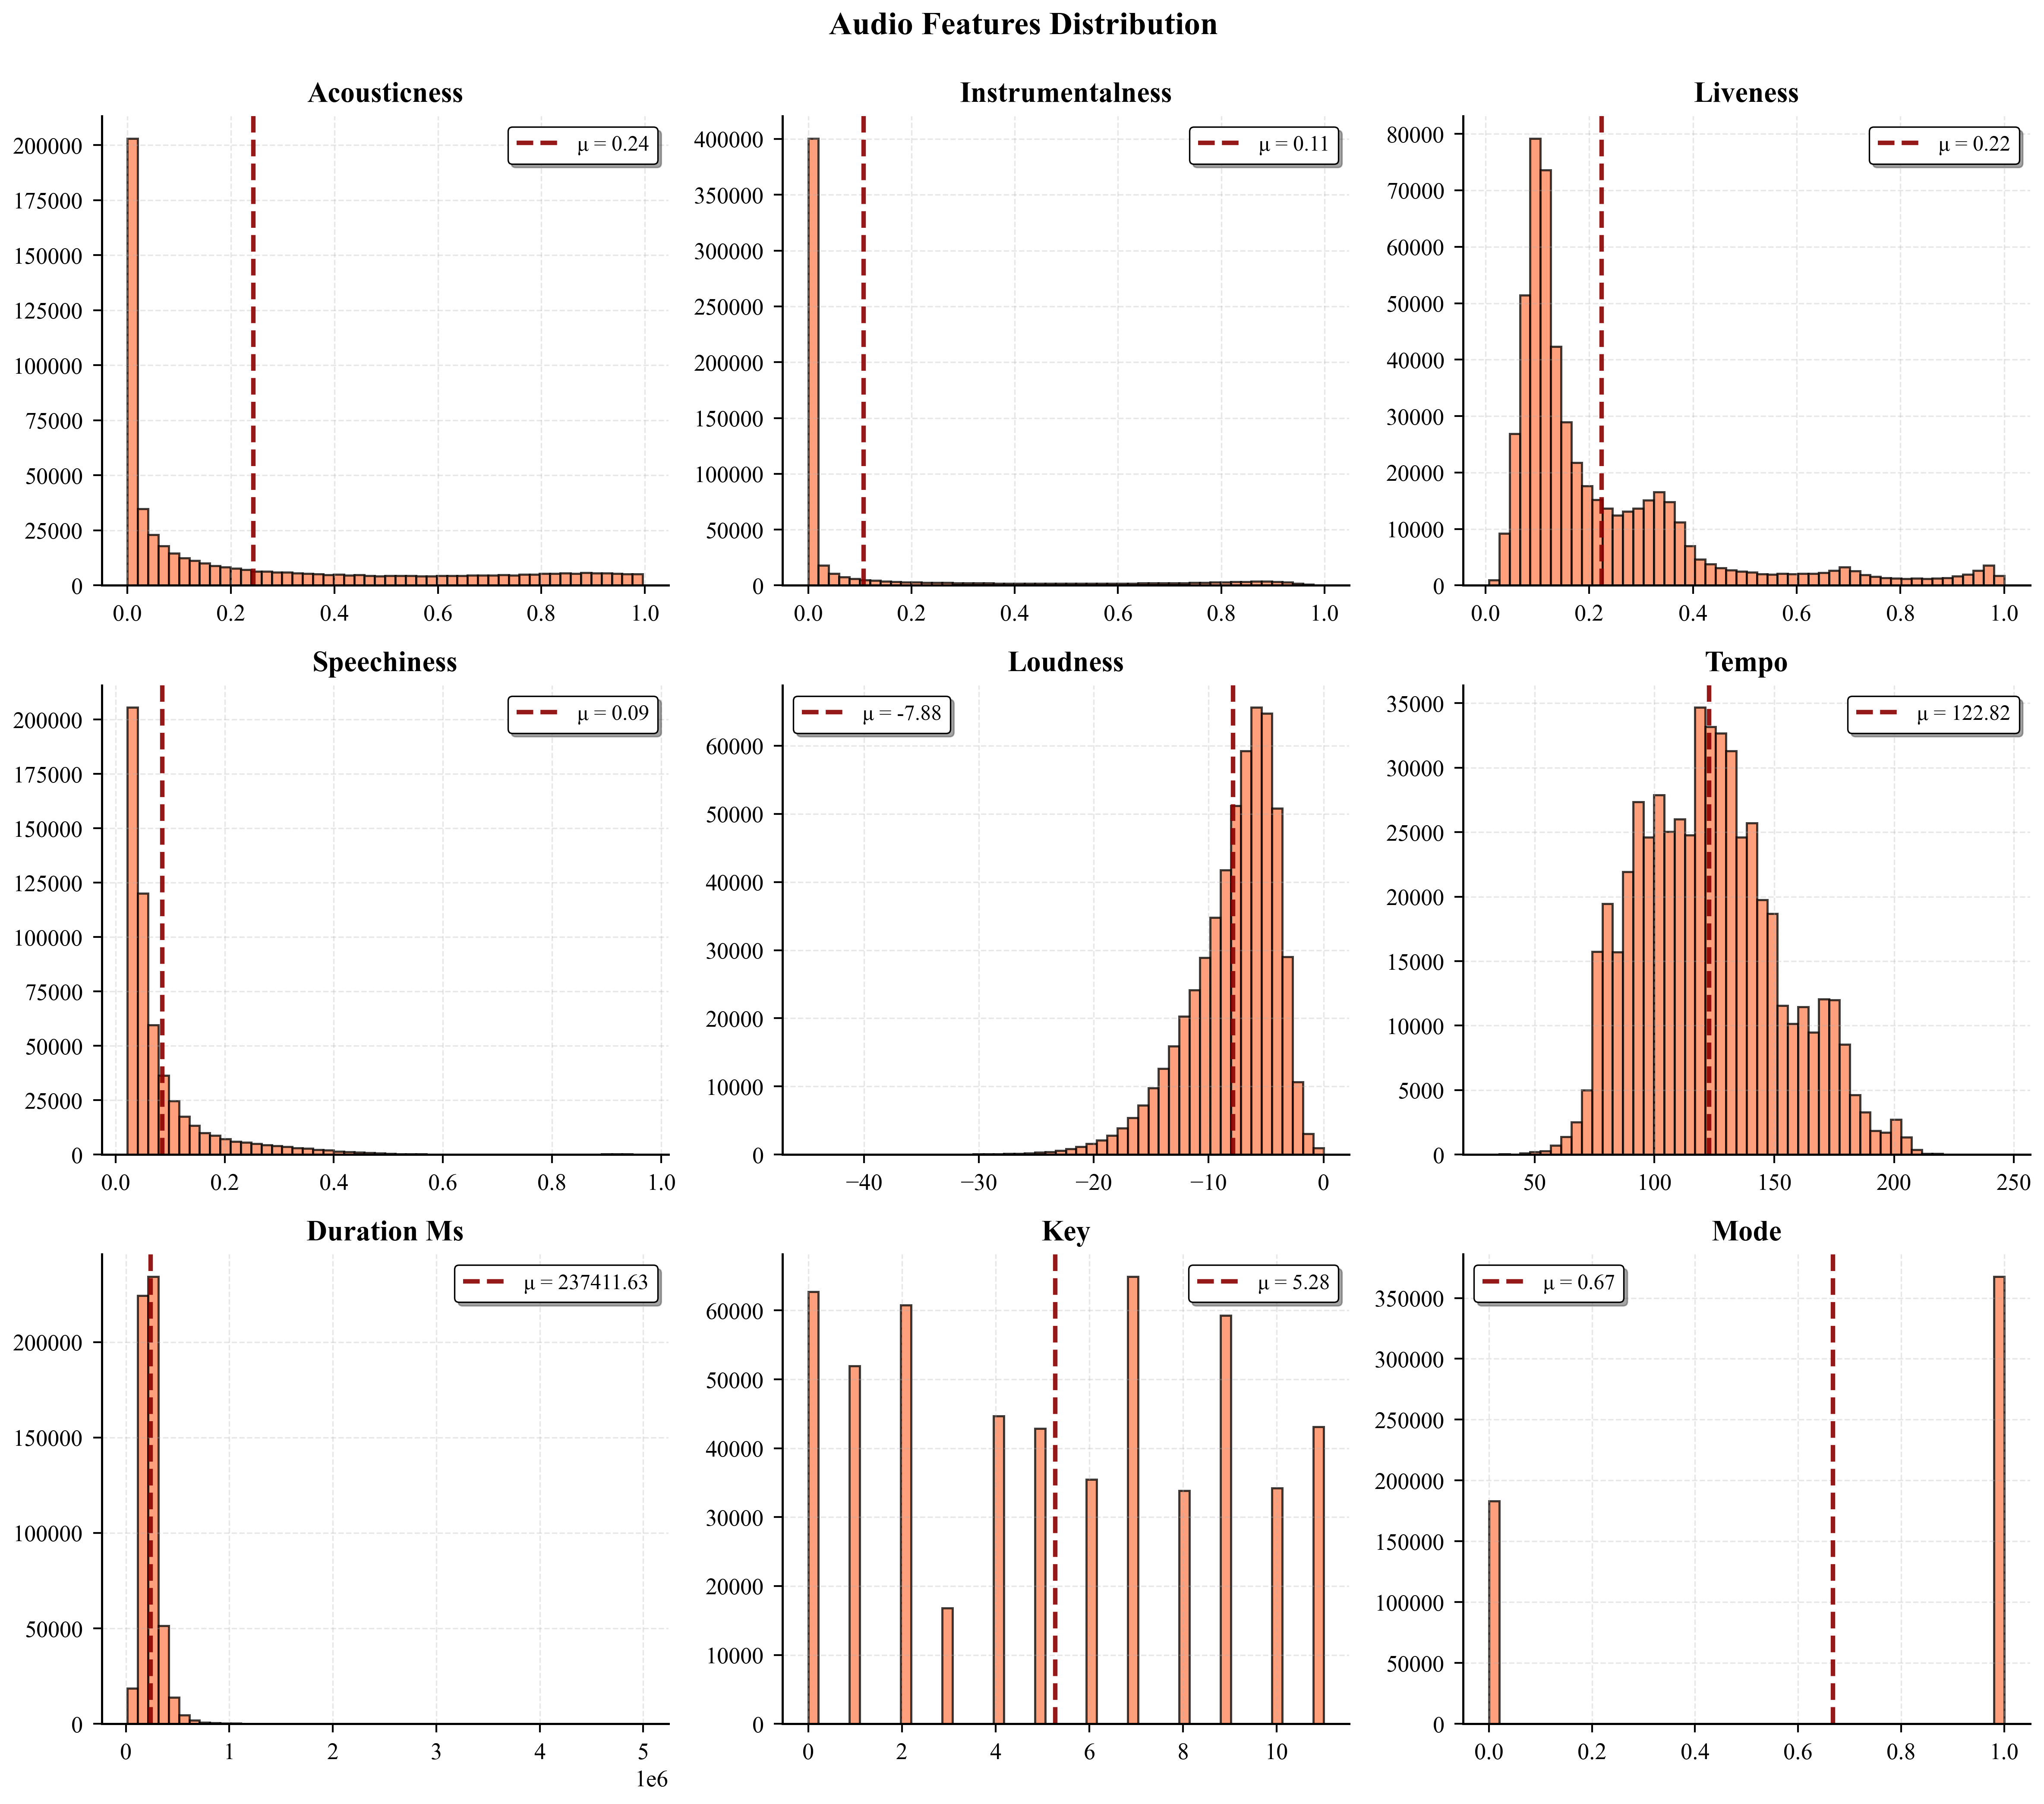

In [12]:
# Audio features distributions - Academic publication style
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Audio Features Distribution', fontsize=18, fontweight='bold', y=0.995)

for idx, feature in enumerate(audio_features):
    ax = axes[idx // 3, idx % 3]
    
    # Histogram
    ax.hist(df[feature].dropna(), bins=50, edgecolor='black', alpha=0.75, 
            color='coral', linewidth=1.2)
    
    # Mean line
    mean_val = df[feature].mean()
    ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2.5, 
               label=f'μ = {mean_val:.2f}', alpha=0.9)
    
    ax.set_title(f'{feature.replace("_", " ").title()}', fontsize=16, fontweight='bold', pad=8)
    ax.legend(loc='best', frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/figures/eda/audio_features_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Correlation Analysis
### How do features relate to our targets?

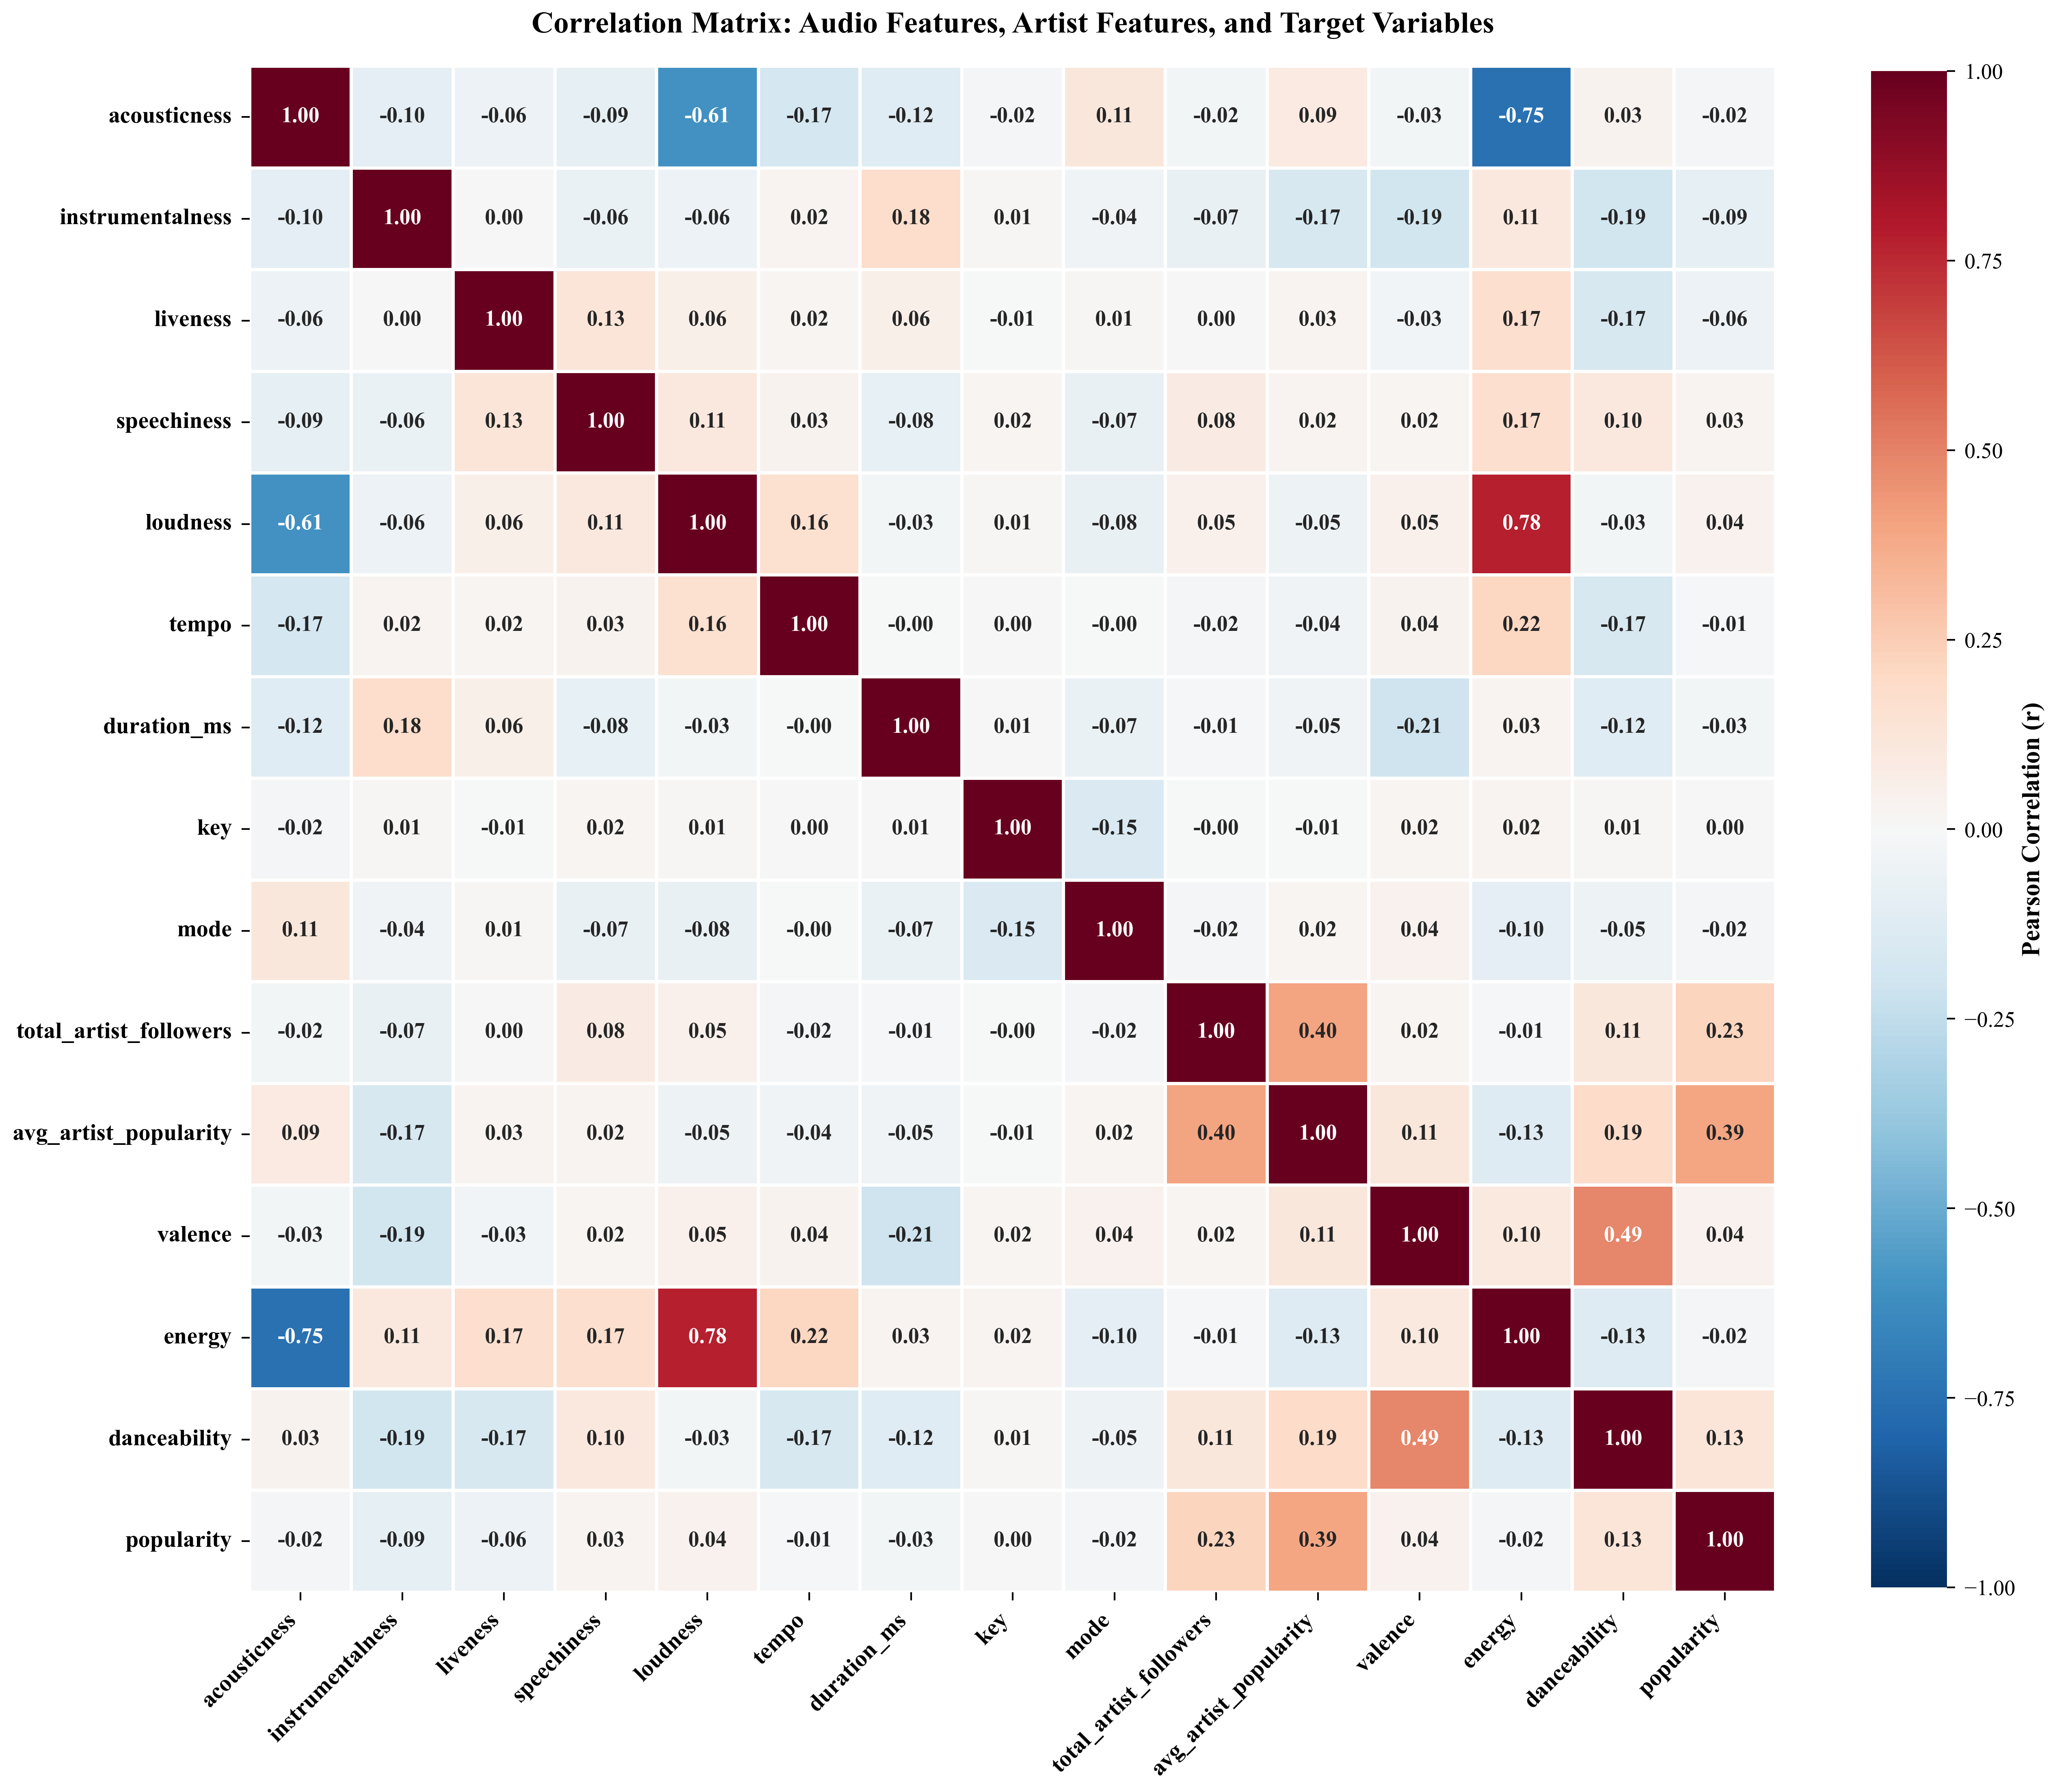

In [13]:
# Correlation matrix: All numeric features (including artist features) - Academic style
correlation_cols = audio_features + artist_features + target_vars
corr_matrix = df[correlation_cols].corr()

# Full correlation heatmap
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1.5, linecolor='white',
            cbar_kws={"shrink": 0.85, "label": "Pearson Correlation (r)"},
            annot_kws={"fontsize": 13, "weight": "bold"},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Matrix: Audio Features, Artist Features, and Target Variables', 
             fontsize=18, fontweight='bold', pad=20)

# Bold labels
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14, fontweight='bold', rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, fontweight='bold', rotation=0)

plt.tight_layout()
plt.savefig('../results/figures/eda/correlation_matrix_with_artist.png', dpi=300, bbox_inches='tight')
plt.show()

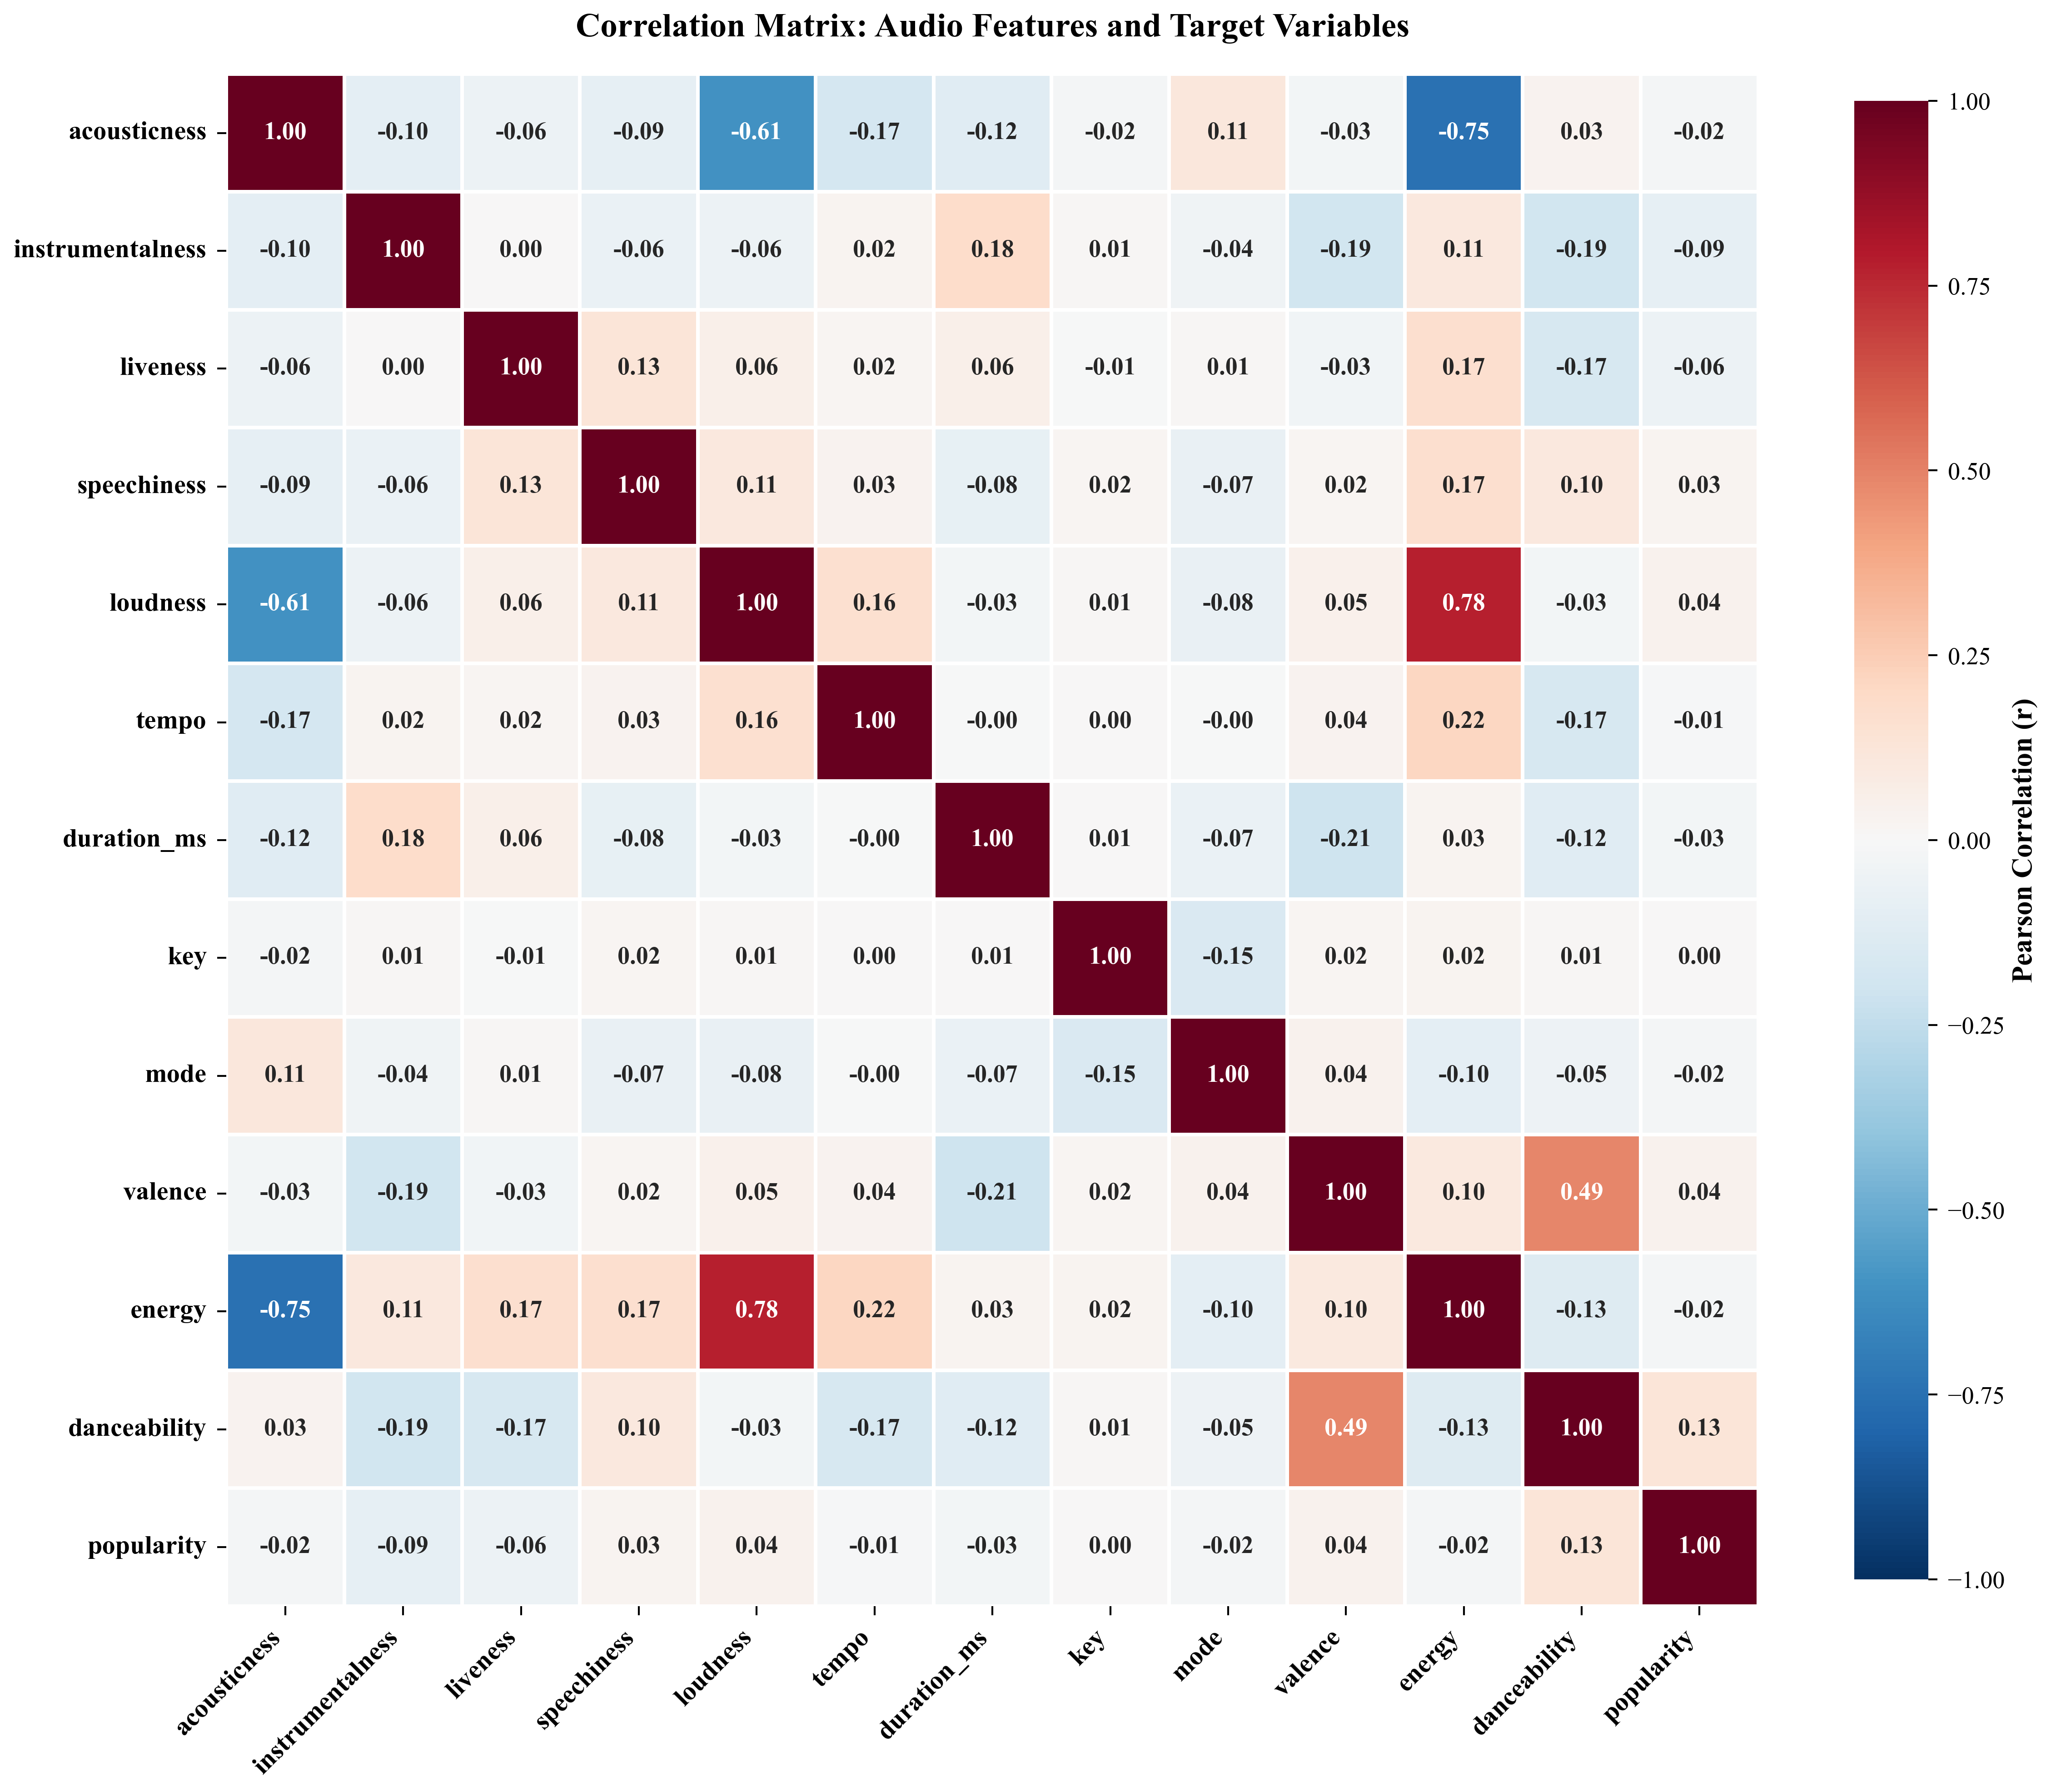

In [14]:
# Correlation matrix: All numeric features - Academic style
correlation_cols = audio_features + target_vars
corr_matrix = df[correlation_cols].corr()

# Full correlation heatmap
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1.5, linecolor='white',
            cbar_kws={"shrink": 0.85, "label": "Pearson Correlation (r)"},
            annot_kws={"fontsize": 13, "weight": "bold"},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Matrix: Audio Features and Target Variables', 
             fontsize=18, fontweight='bold', pad=20)

# Bold labels
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14, fontweight='bold', rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, fontweight='bold', rotation=0)

plt.tight_layout()
plt.savefig('../results/figures/eda/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

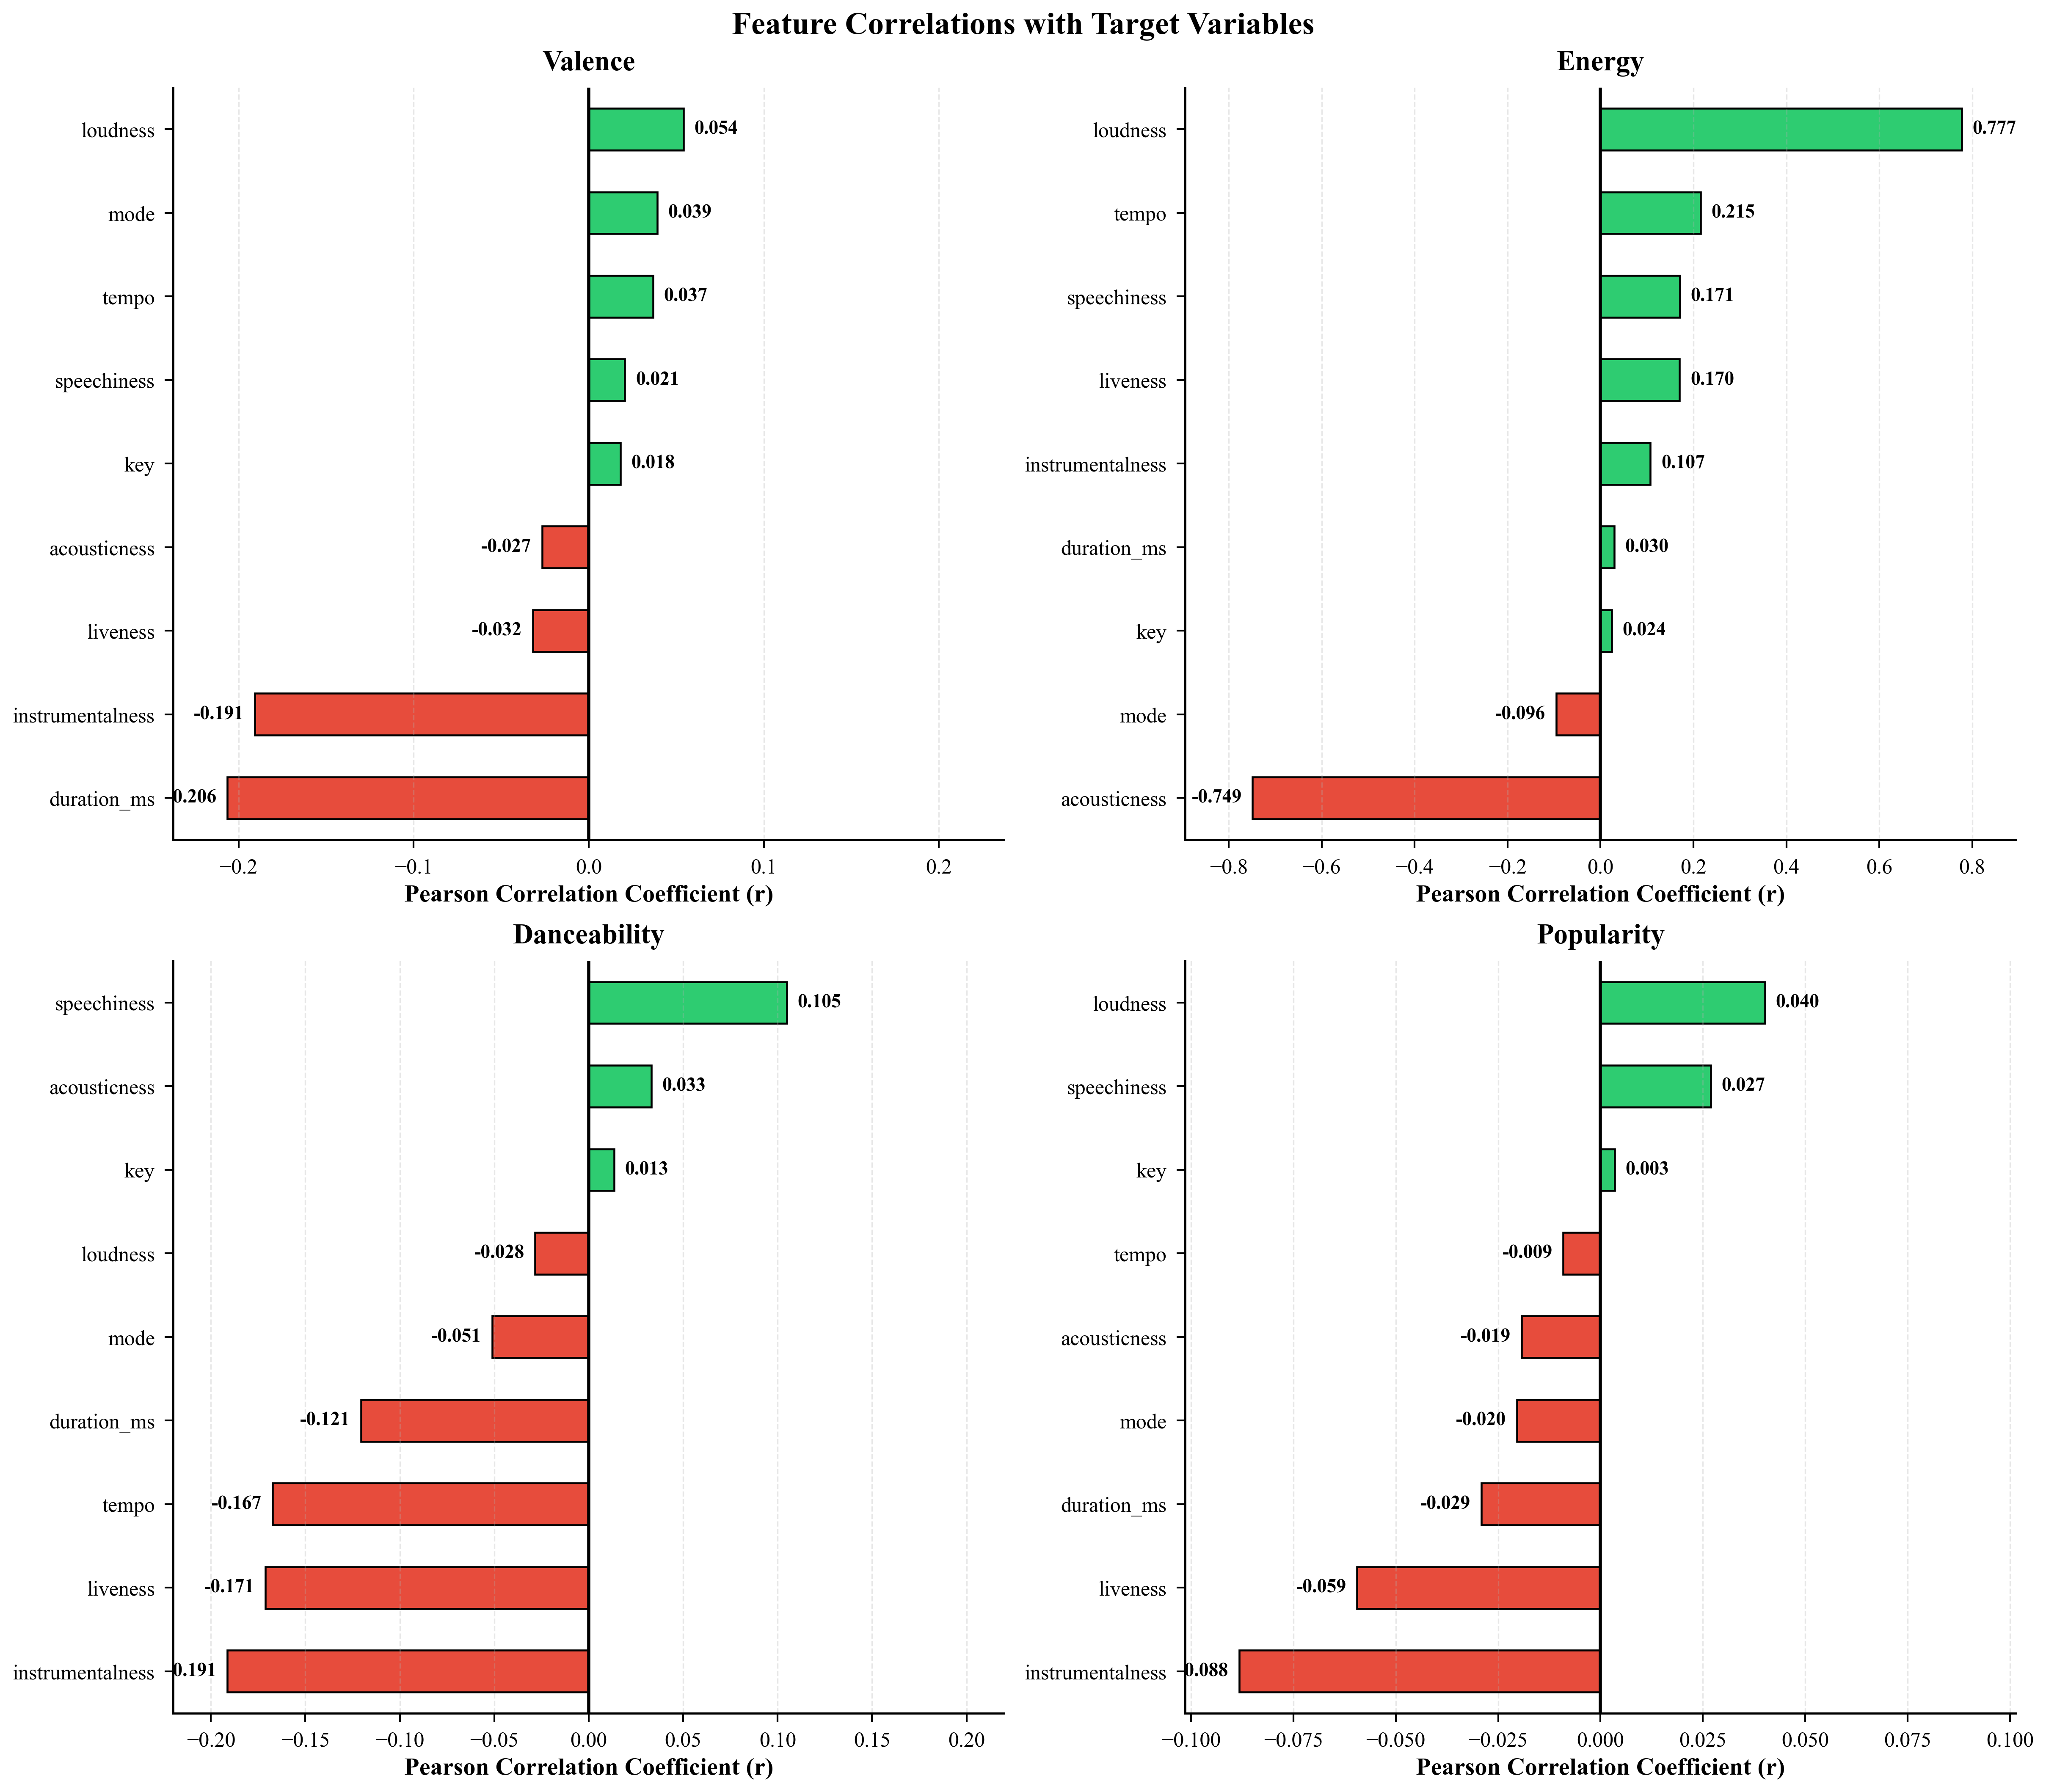


TABLE 2: Top Correlations with Target Variables

VALENCE:
  Top 3 Positive: {'loudness': 0.05413256594936019, 'mode': 0.0391793794998141, 'tempo': 0.036665021636036105}
  Top 3 Negative: {'liveness': -0.03185089076927821, 'instrumentalness': -0.1906774715713386, 'duration_ms': -0.20628972148214103}

ENERGY:
  Top 3 Positive: {'loudness': 0.7773572777461041, 'tempo': 0.2154104762432953, 'speechiness': 0.17056200225782805}
  Top 3 Negative: {'key': 0.024046314399993978, 'mode': -0.0955559644732214, 'acousticness': -0.7486807976559301}

DANCEABILITY:
  Top 3 Positive: {'speechiness': 0.10478399708977469, 'acousticness': 0.03305611950231806, 'key': 0.013366253654695685}
  Top 3 Negative: {'tempo': -0.1673169399313942, 'liveness': -0.17110365145967563, 'instrumentalness': -0.19121593752421495}

POPULARITY:
  Top 3 Positive: {'loudness': 0.040155426724961404, 'speechiness': 0.026919068137383966, 'key': 0.003474318682542132}
  Top 3 Negative: {'duration_ms': -0.029100417584255713, 'liveness'

In [31]:
# Correlation with each target (separate analysis) - Academic style
fig, axes = plt.subplots(2, 2, figsize=(16, 14), constrained_layout=True)

fig.suptitle('Feature Correlations with Target Variables',
    fontsize=18,
    fontweight='bold')

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]

    target_corr = (df[audio_features + [target]]
                   .corr()[target]
                   .drop(target)
                   .sort_values())

    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in target_corr]

    target_corr.plot(
        kind='barh',
        ax=ax,
        color=colors,
        edgecolor='black',
        linewidth=1.1
    )

    # Axis formatting
    ax.set_title(target.capitalize(), fontsize=16, fontweight='bold', pad=10)
    ax.set_xlabel('Pearson Correlation Coefficient (r)', fontsize=14)
    ax.axvline(0, color='black', linewidth=1.8)
    ax.grid(True, axis='x', linestyle='--', alpha=0.3)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(axis='x', labelsize=12)

    # Symmetric x-limits for visual balance
    max_val = max(abs(target_corr.min()), abs(target_corr.max()))
    ax.set_xlim(-max_val * 1.15, max_val * 1.15)

    # Dynamic label offset
    offset = max_val * 0.03

    for i, value in enumerate(target_corr):
        ax.text(
            value + offset if value > 0 else value - offset,
            i,
            f'{value:.3f}',
            va='center',
            ha='left' if value > 0 else 'right',
            fontsize=11,
            fontweight='bold',
            clip_on=True
        )

plt.savefig(
    '../results/figures/eda/target_correlations.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Print top correlations for each target
print("\n" + "="*80)
print("TABLE 2: Top Correlations with Target Variables")
print("="*80)
for target in target_vars:
    target_corr = df[audio_features + [target]].corr()[target].drop(target).sort_values(ascending=False)
    print(f"\n{target.upper()}:")
    print(f"  Top 3 Positive: {target_corr.head(3).to_dict()}")
    print(f"  Top 3 Negative: {target_corr.tail(3).to_dict()}")
print("="*80)

## 6. Genre Analysis
### How do targets vary by genre?

Total unique genres: 10

Top 10 genres:
genre
Rock          197168
Pop            72539
Electronic     69755
Folk           50843
Country        46076
Hip-Hop        41745
R&B            27337
Jazz           17010
Blues          15976
Classical      12173
Name: count, dtype: int64


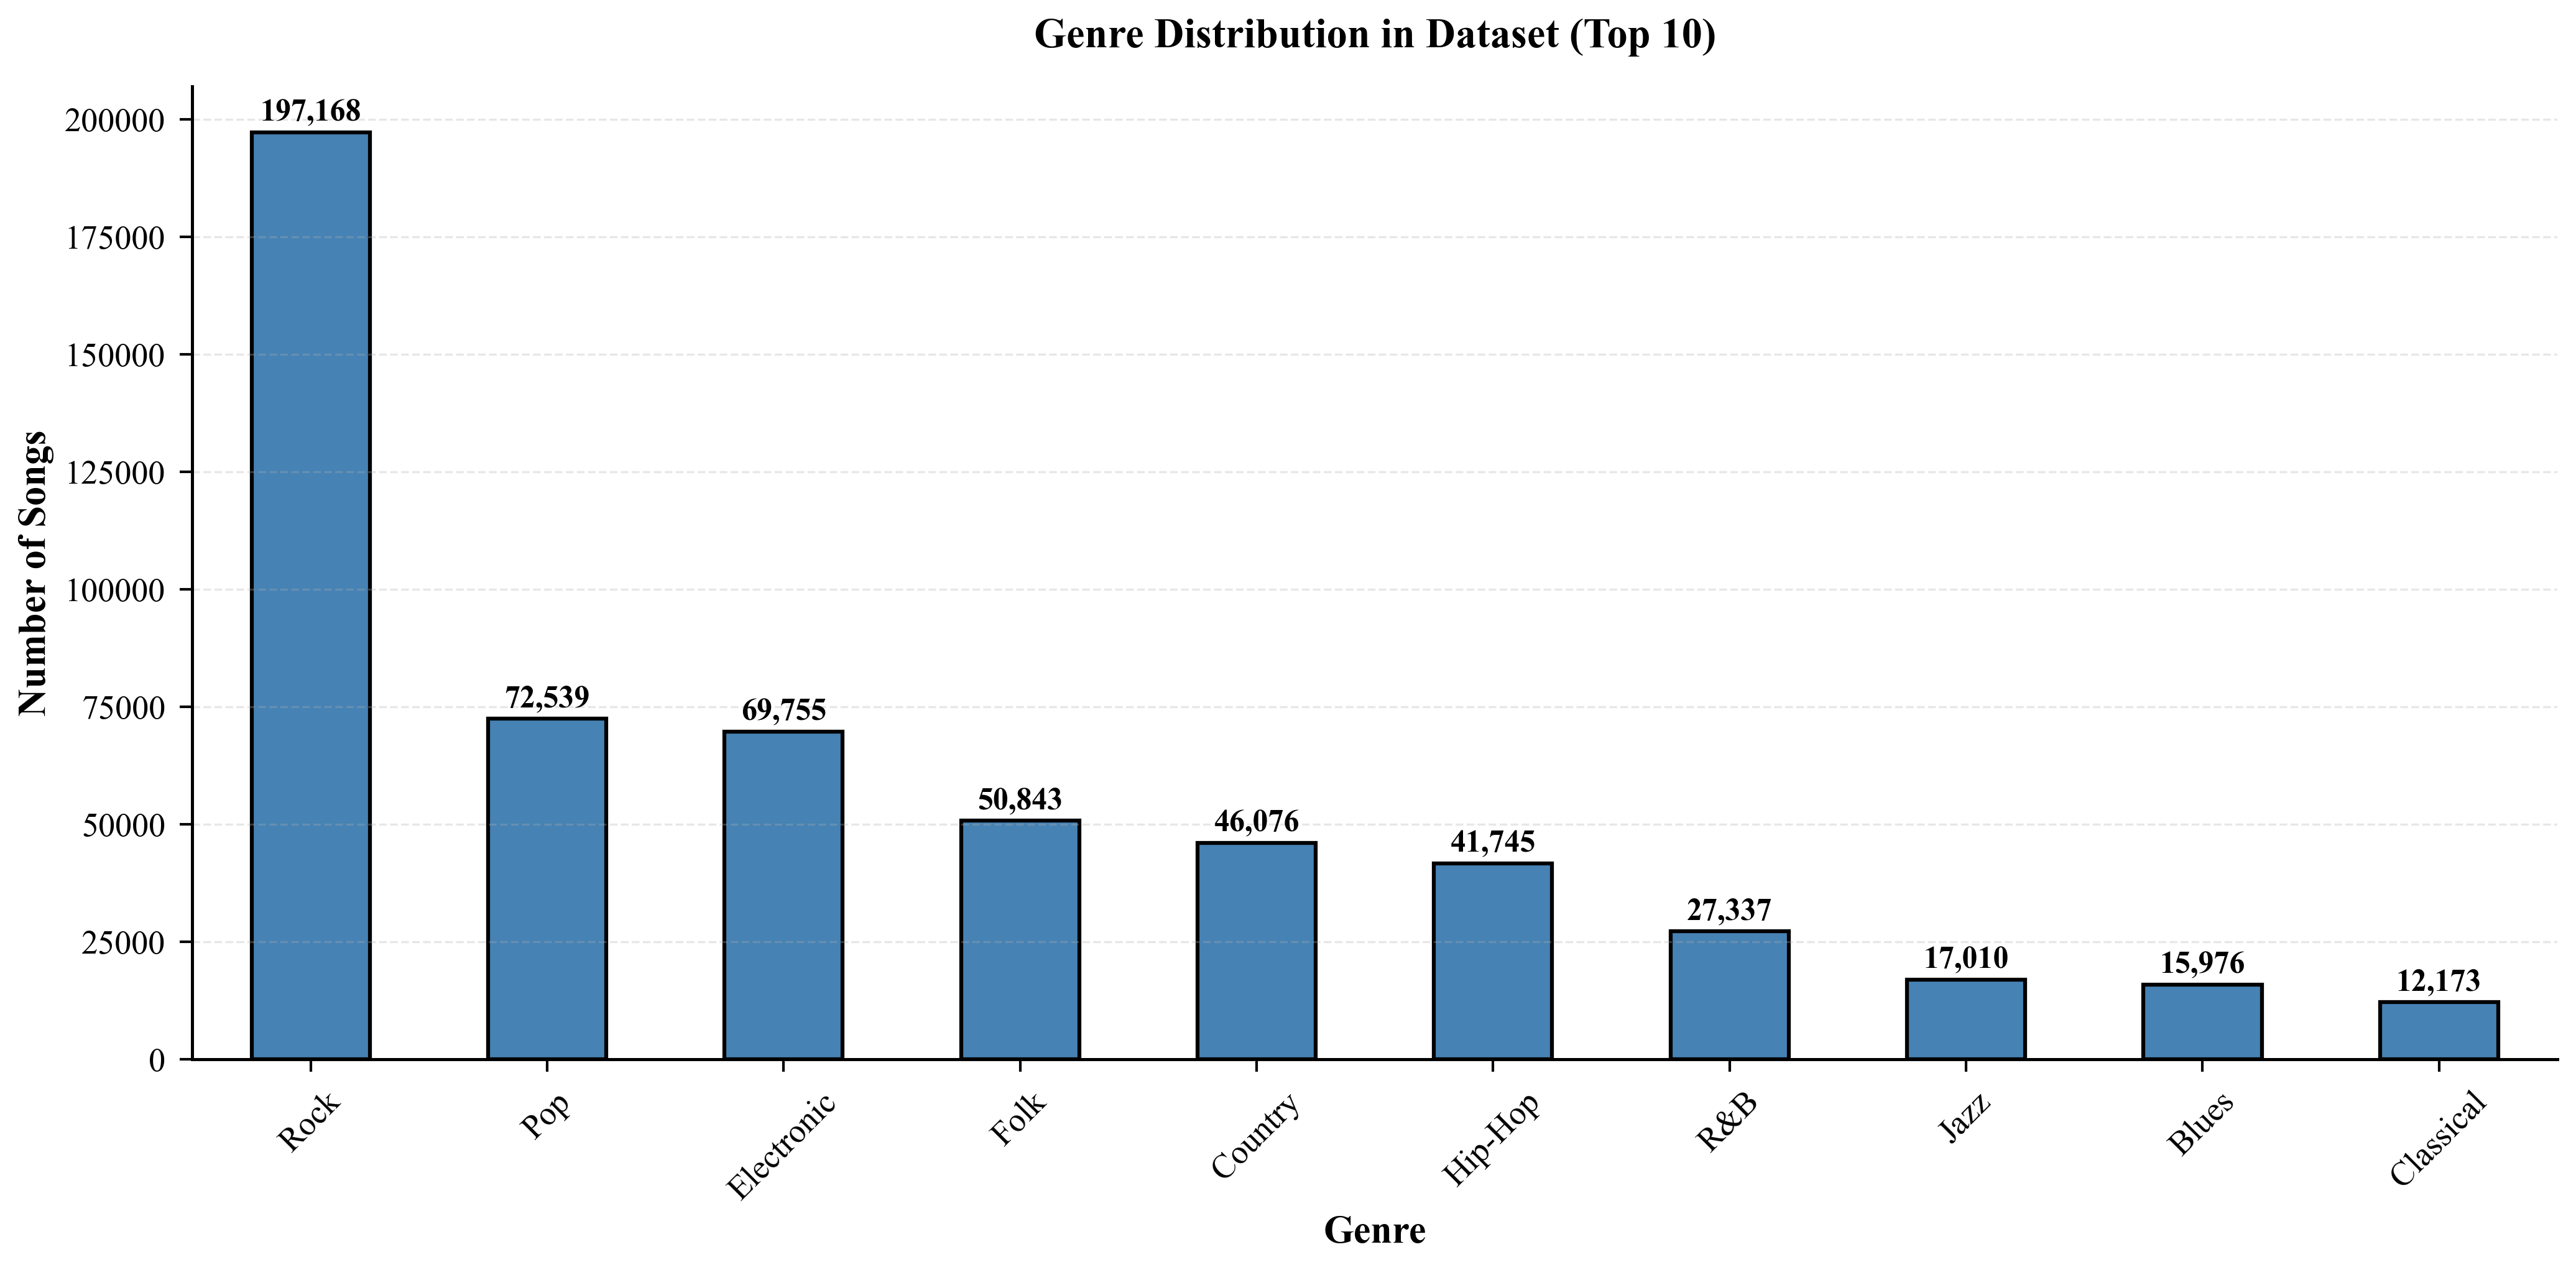

In [16]:
# Genre distribution - Academic style
genre_counts = df['genre'].value_counts()

print(f"Total unique genres: {len(genre_counts)}")
print(f"\nTop 10 genres:")
print(genre_counts.head(10))

# Visualize top 10 genres
fig, ax = plt.subplots(figsize=(14, 7))
bars = genre_counts.head(10).plot(kind='bar', color='steelblue', edgecolor='black', 
                                   linewidth=1.5, ax=ax)

ax.set_title('Genre Distribution in Dataset (Top 10)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Genre', fontsize=15, fontweight='bold')
ax.set_ylabel('Number of Songs', fontsize=15, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on bars
for i, (idx, value) in enumerate(genre_counts.head(10).items()):
    ax.text(i, value + 1000, f'{value:,}', ha='center', va='bottom', 
            fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/eda/genre_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

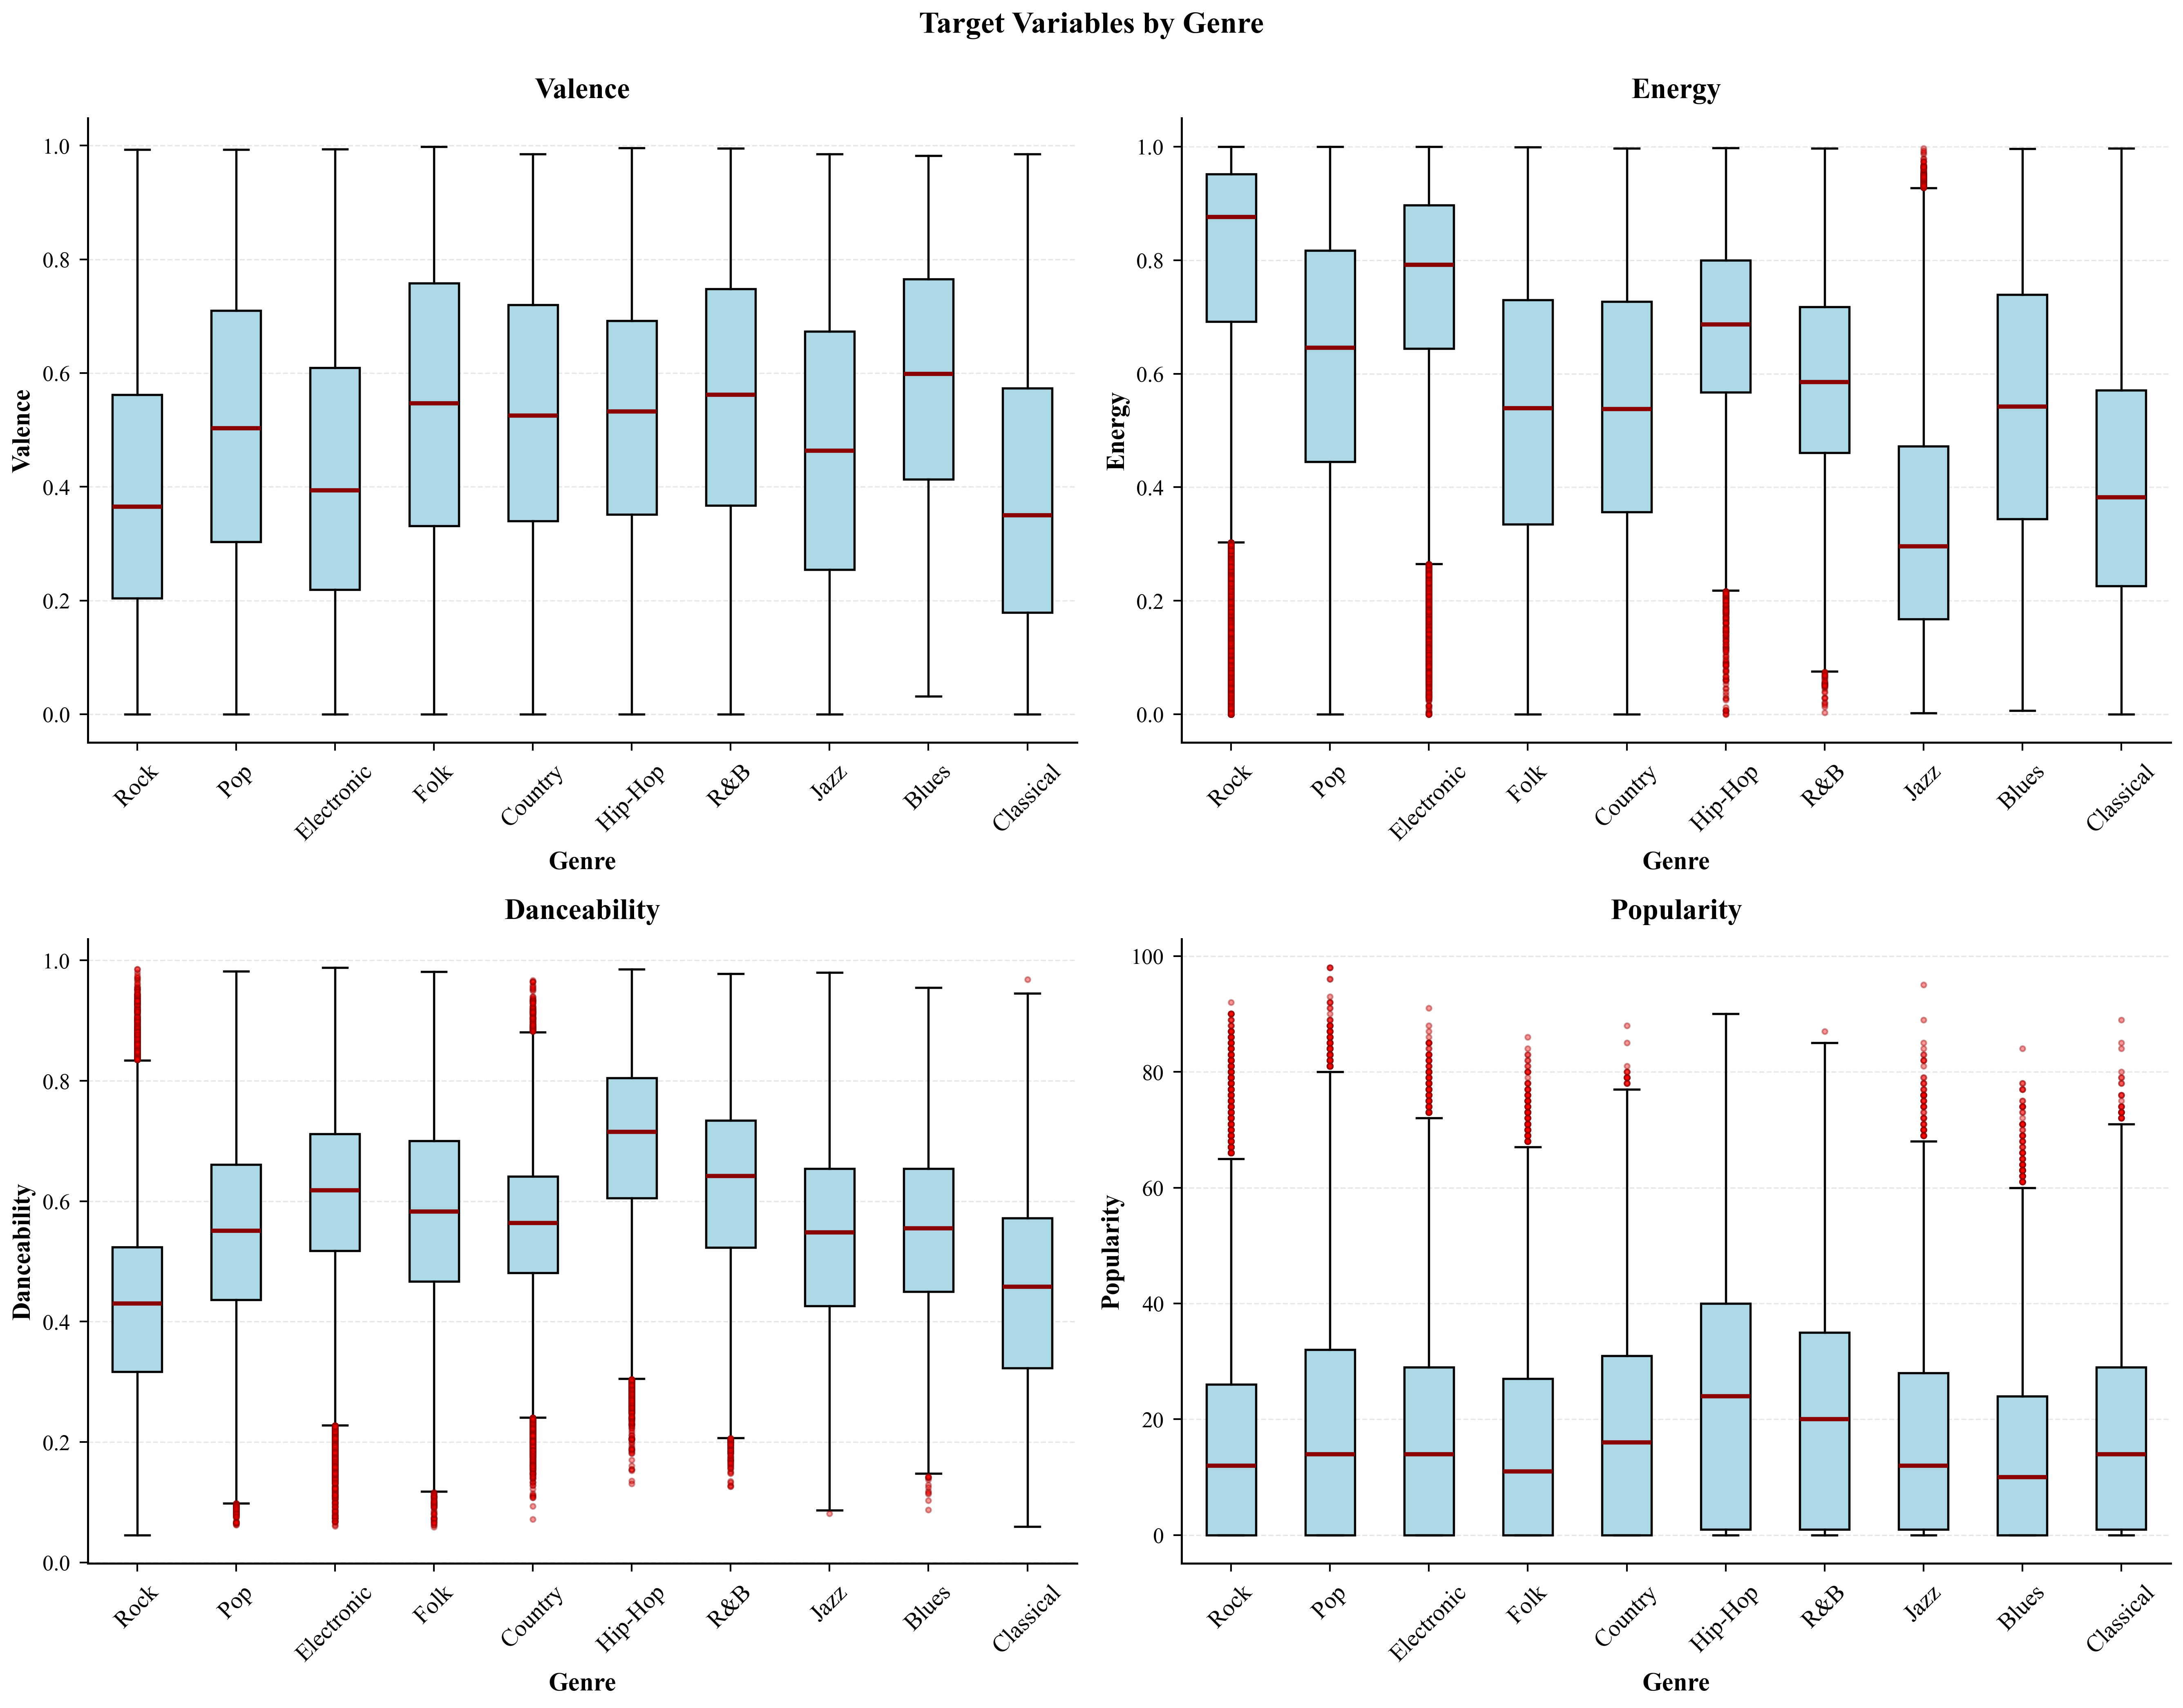

In [17]:
# Target variables by top genres - Academic style
top_genres = genre_counts.head(10).index
df_top_genres = df[df['genre'].isin(top_genres)]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Target Variables by Genre', fontsize=18, fontweight='bold', y=0.995)

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]
    
    # Prepare data for box plot
    data_by_genre = [df_top_genres[df_top_genres['genre'] == g][target].dropna() 
                     for g in top_genres]
    
    # Box plot with academic styling
    bp = ax.boxplot(data_by_genre, labels=top_genres, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.3),
                    medianprops=dict(color='darkred', linewidth=2.5),
                    whiskerprops=dict(color='black', linewidth=1.3),
                    capprops=dict(color='black', linewidth=1.3),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=3, 
                                   alpha=0.4, markeredgecolor='darkred'))
    
    ax.set_xlabel('Genre', fontsize=15, fontweight='bold')
    ax.set_ylabel(target.capitalize(), fontsize=15, fontweight='bold')
    ax.set_title(f'{target.capitalize()}', fontsize=17, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/figures/eda/targets_by_genre.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Mean target values by genre
genre_means = df.groupby('genre')[target_vars].mean().sort_values('valence', ascending=False)

print("\nTop 5 Happiest Genres (by valence):")
print(genre_means.head(5).round(3))

print("\nTop 5 Saddest Genres (by valence):")
print(genre_means.tail(5).round(3))


Top 5 Happiest Genres (by valence):
         valence  energy  danceability  popularity
genre                                             
Blues      0.584   0.539         0.550      14.165
R&B        0.555   0.585         0.624      21.324
Folk       0.542   0.535         0.580      15.528
Country    0.530   0.538         0.557      18.486
Hip-Hop    0.519   0.678         0.698      24.579

Top 5 Saddest Genres (by valence):
            valence  energy  danceability  popularity
genre                                                
Pop           0.507   0.619         0.544      18.827
Jazz          0.471   0.337         0.536      16.448
Electronic    0.426   0.750         0.609      17.181
Rock          0.398   0.796         0.424      15.944
Classical     0.391   0.409         0.449      17.554


## 7. Year Analysis
### How has music evolved over time?

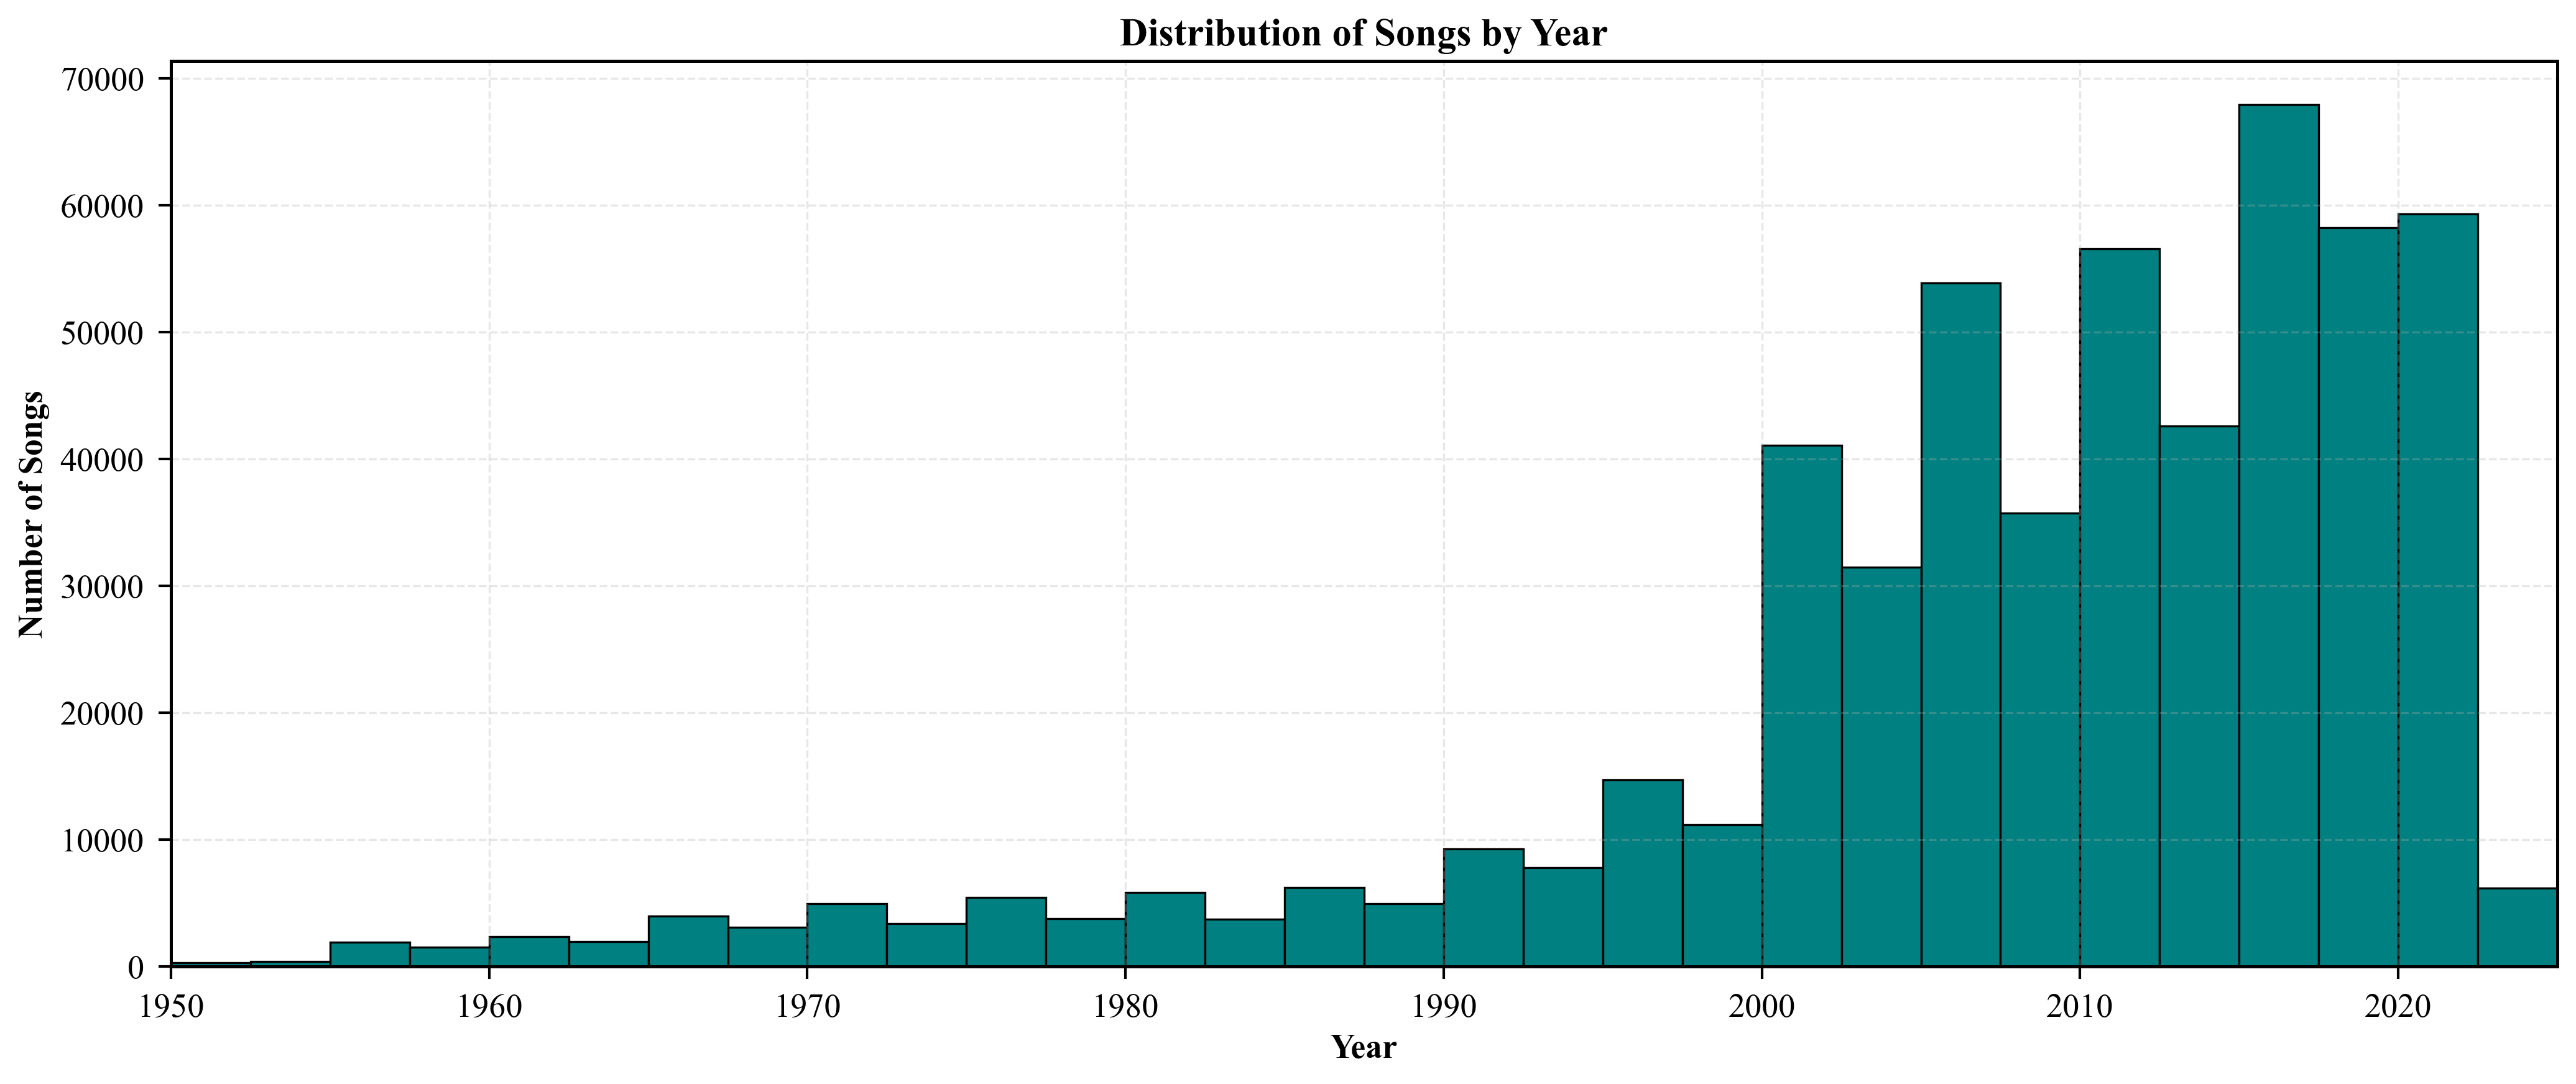

Year range: 1950 - 2025
Median year: 2010.0
Mean year: 2007.1


In [19]:
# Year distribution
plt.figure(figsize=(14, 6))
df['year'].hist(bins=50, edgecolor='black', color='teal')
plt.title('Distribution of Songs by Year', fontsize=15, fontweight='bold')
plt.xlabel('Year', fontsize=13)
plt.ylabel('Number of Songs', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xlim(1950, df['year'].max())
plt.show()

print(f"Year range: {1950} - {df['year'].max()}")
print(f"Median year: {df['year'].median()}")
print(f"Mean year: {df['year'].mean():.1f}")

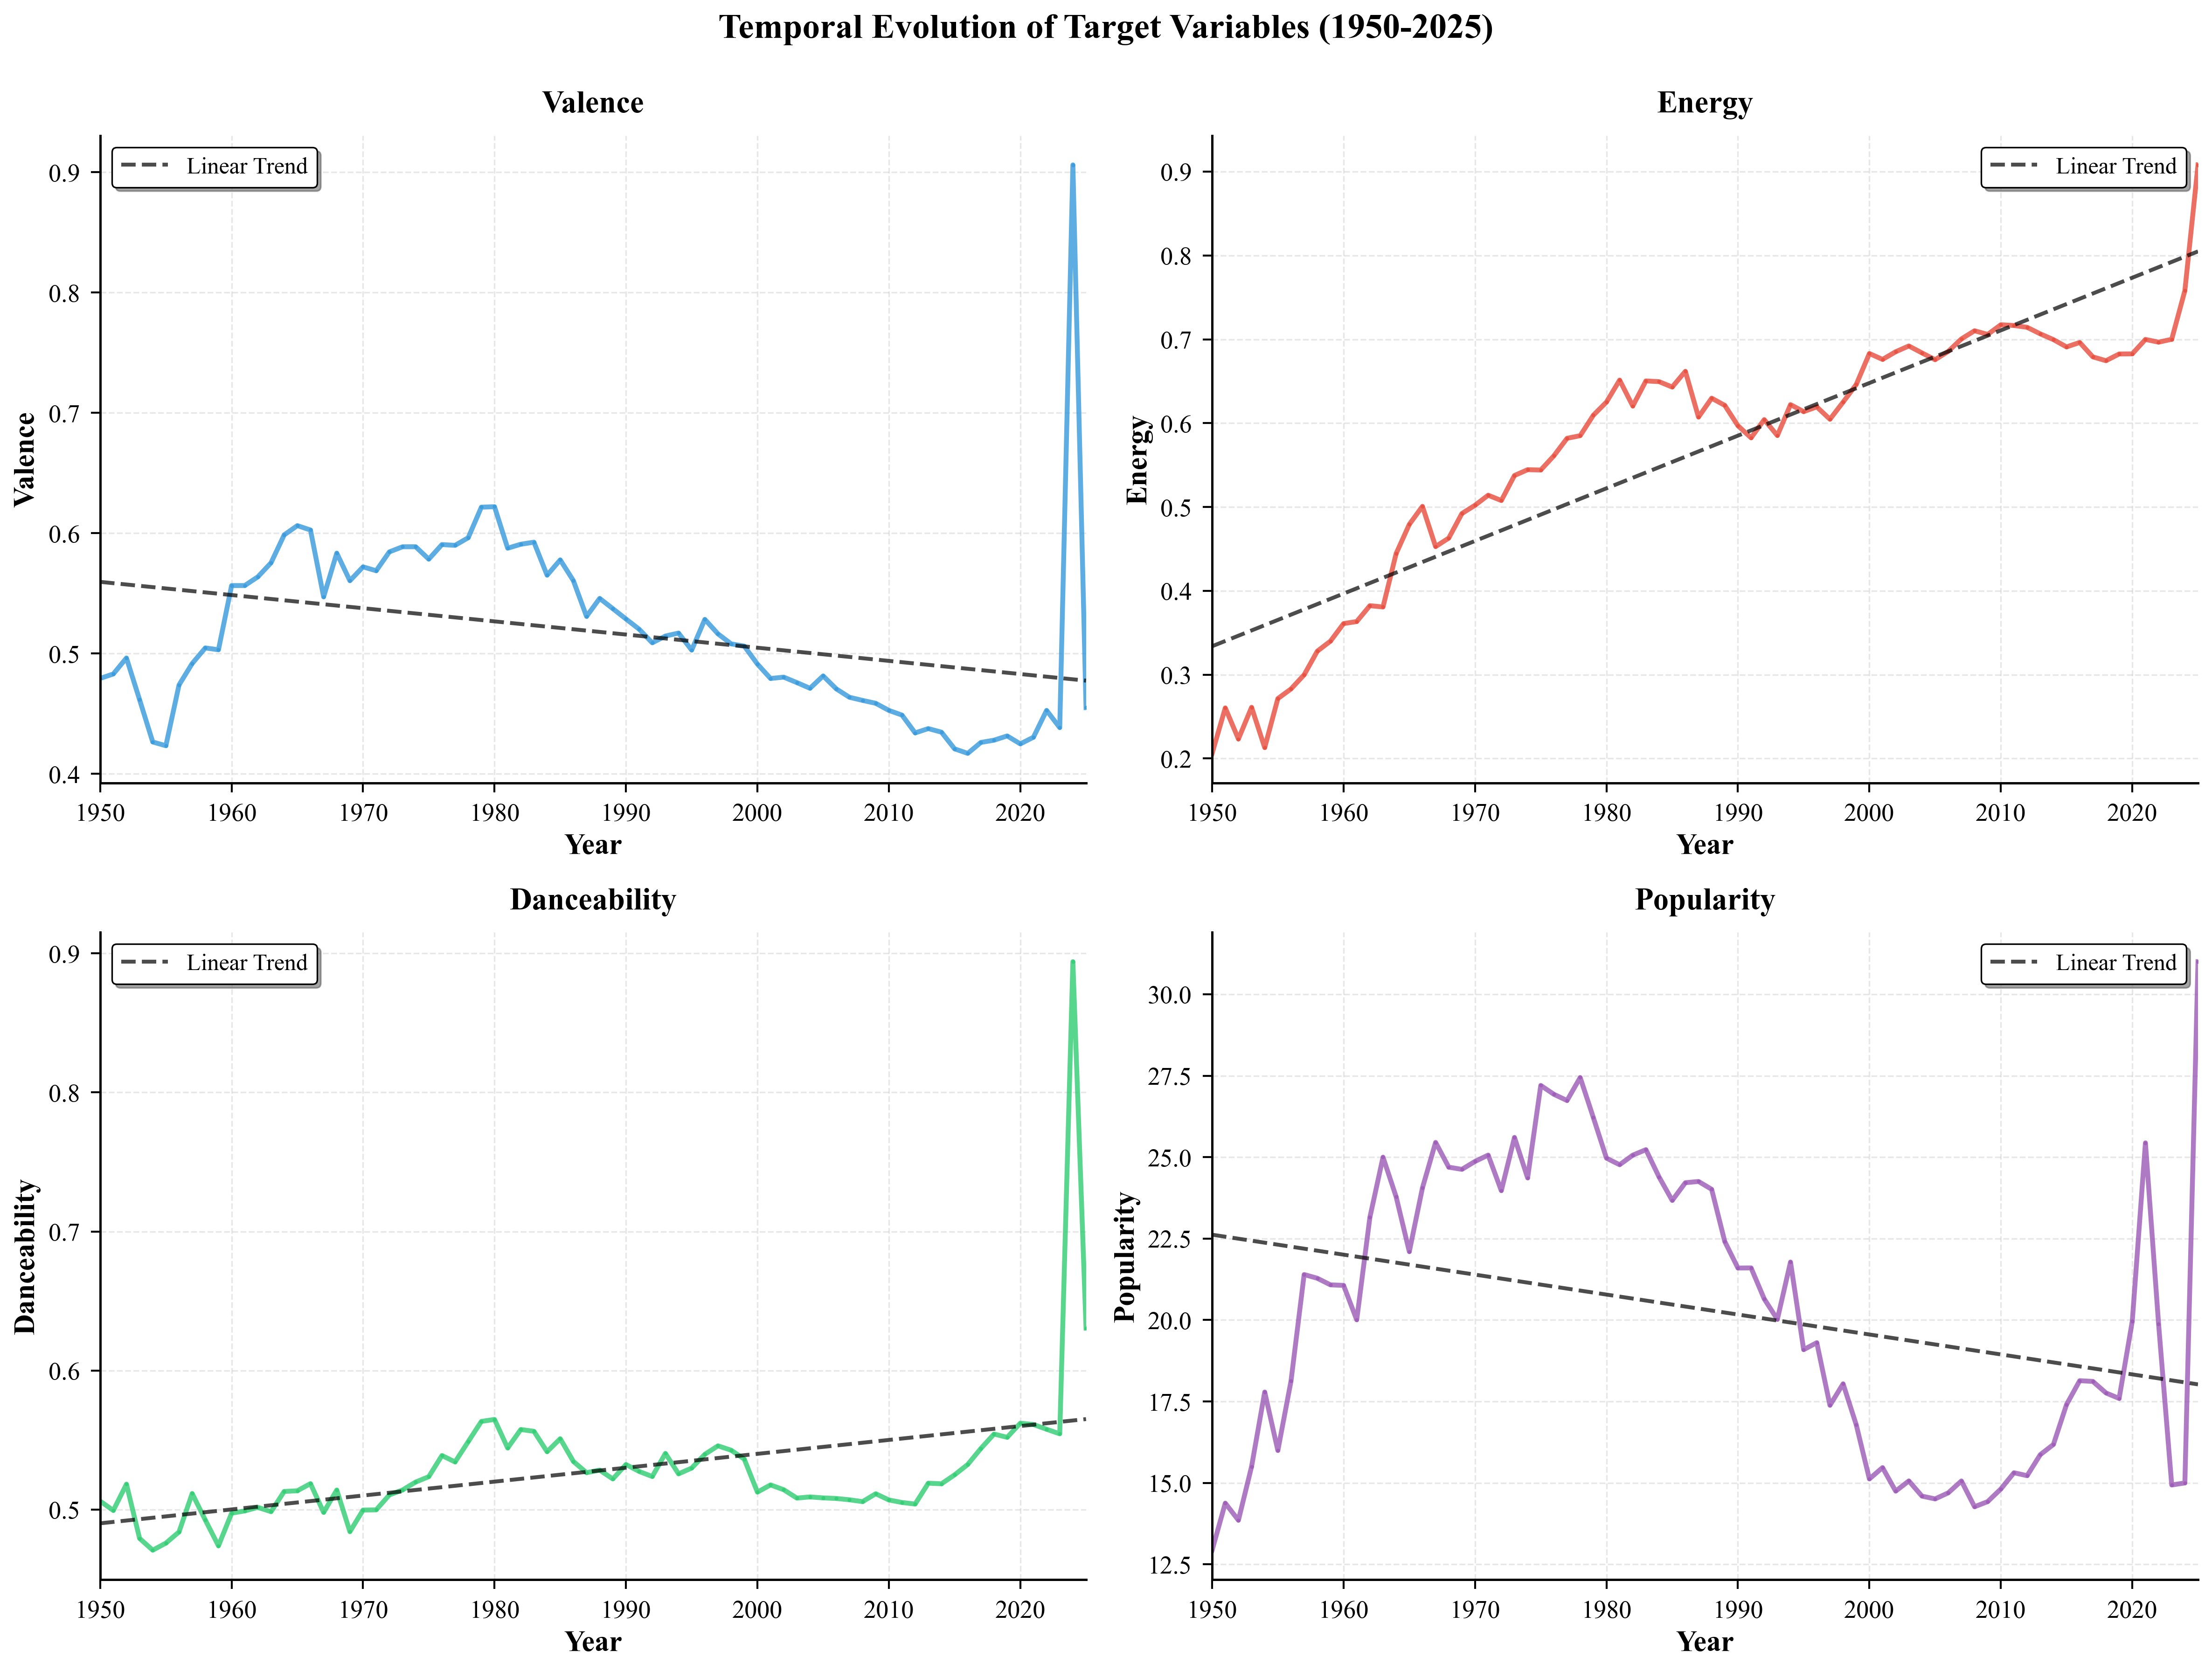

In [20]:
# Target trends over time - Academic style
# Group by year and calculate means (start from 1950)
year_trends = df[df['year'] >= 1950].groupby('year')[target_vars].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Temporal Evolution of Target Variables ({year_trends.index.min()}-{year_trends.index.max()})', 
             fontsize=18, fontweight='bold', y=0.995)

colors_map = {'valence': '#3498db', 'energy': '#e74c3c', 
              'danceability': '#2ecc71', 'popularity': '#9b59b6'}

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]
    
    # Line plot with markers
    ax.plot(year_trends.index, year_trends[target], linewidth=2.5, 
            color=colors_map[target], marker='o', markersize=2, alpha=0.8)
    
    # Add trend line
    z = np.polyfit(year_trends.index, year_trends[target], 1)
    p = np.poly1d(z)
    ax.plot(year_trends.index, p(year_trends.index), "--", 
            color='black', linewidth=2, alpha=0.7, label='Linear Trend')
    
    ax.set_xlabel('Year', fontsize=15, fontweight='bold')
    ax.set_ylabel(target.capitalize(), fontsize=15, fontweight='bold')
    ax.set_title(f'{target.capitalize()}', fontsize=16, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', frameon=True, shadow=True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Ensure x-axis starts at 1950 (or the first year in year_trends) and ends at the max year present
    ax.set_xlim(year_trends.index.min(), year_trends.index.max())

plt.tight_layout()
plt.savefig('../results/figures/eda/temporal_trends.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Lyrics Analysis
### Basic text statistics

In [21]:
# Lyrics availability
has_lyrics = df['lyrics'].notna() & (df['lyrics'].str.strip() != '')

# Check if lyrics length is less than song name length (likely invalid)
invalid_lyrics = has_lyrics & (df['lyrics'].str.strip().str.len() < df['name'].str.len() * 4)

# Update has_lyrics to exclude invalid lyrics
has_lyrics = has_lyrics & ~invalid_lyrics

print(f"Songs with valid lyrics: {has_lyrics.sum():,} ({has_lyrics.sum()/len(df)*100:.2f}%)")
print(f"Songs without lyrics: {(~has_lyrics).sum():,} ({(~has_lyrics).sum()/len(df)*100:.2f}%)")
print(f"  - Invalid lyrics (shorter than song name): {invalid_lyrics.sum():,}")

Songs with valid lyrics: 549,546 (99.80%)
Songs without lyrics: 1,076 (0.20%)
  - Invalid lyrics (shorter than song name): 1,076


In [22]:
# Basic lyrics statistics (on a sample to avoid memory issues)
sample_size = min(10000, has_lyrics.sum())
df_with_lyrics = df[has_lyrics].sample(n=sample_size, random_state=42)

# Calculate basic stats
df_with_lyrics['word_count'] = df_with_lyrics['lyrics'].str.split().str.len()
df_with_lyrics['char_count'] = df_with_lyrics['lyrics'].str.len()

print(f"\nLyrics Statistics (sample of {sample_size:,} songs):")
print(df_with_lyrics[['word_count', 'char_count']].describe().round(1))


Lyrics Statistics (sample of 10,000 songs):
       word_count  char_count
count     10000.0     10000.0
mean        250.5      1267.7
std         154.7       782.2
min           7.0        35.0
25%         150.0       763.0
50%         217.0      1099.0
75%         304.0      1529.2
max        1612.0      8315.0


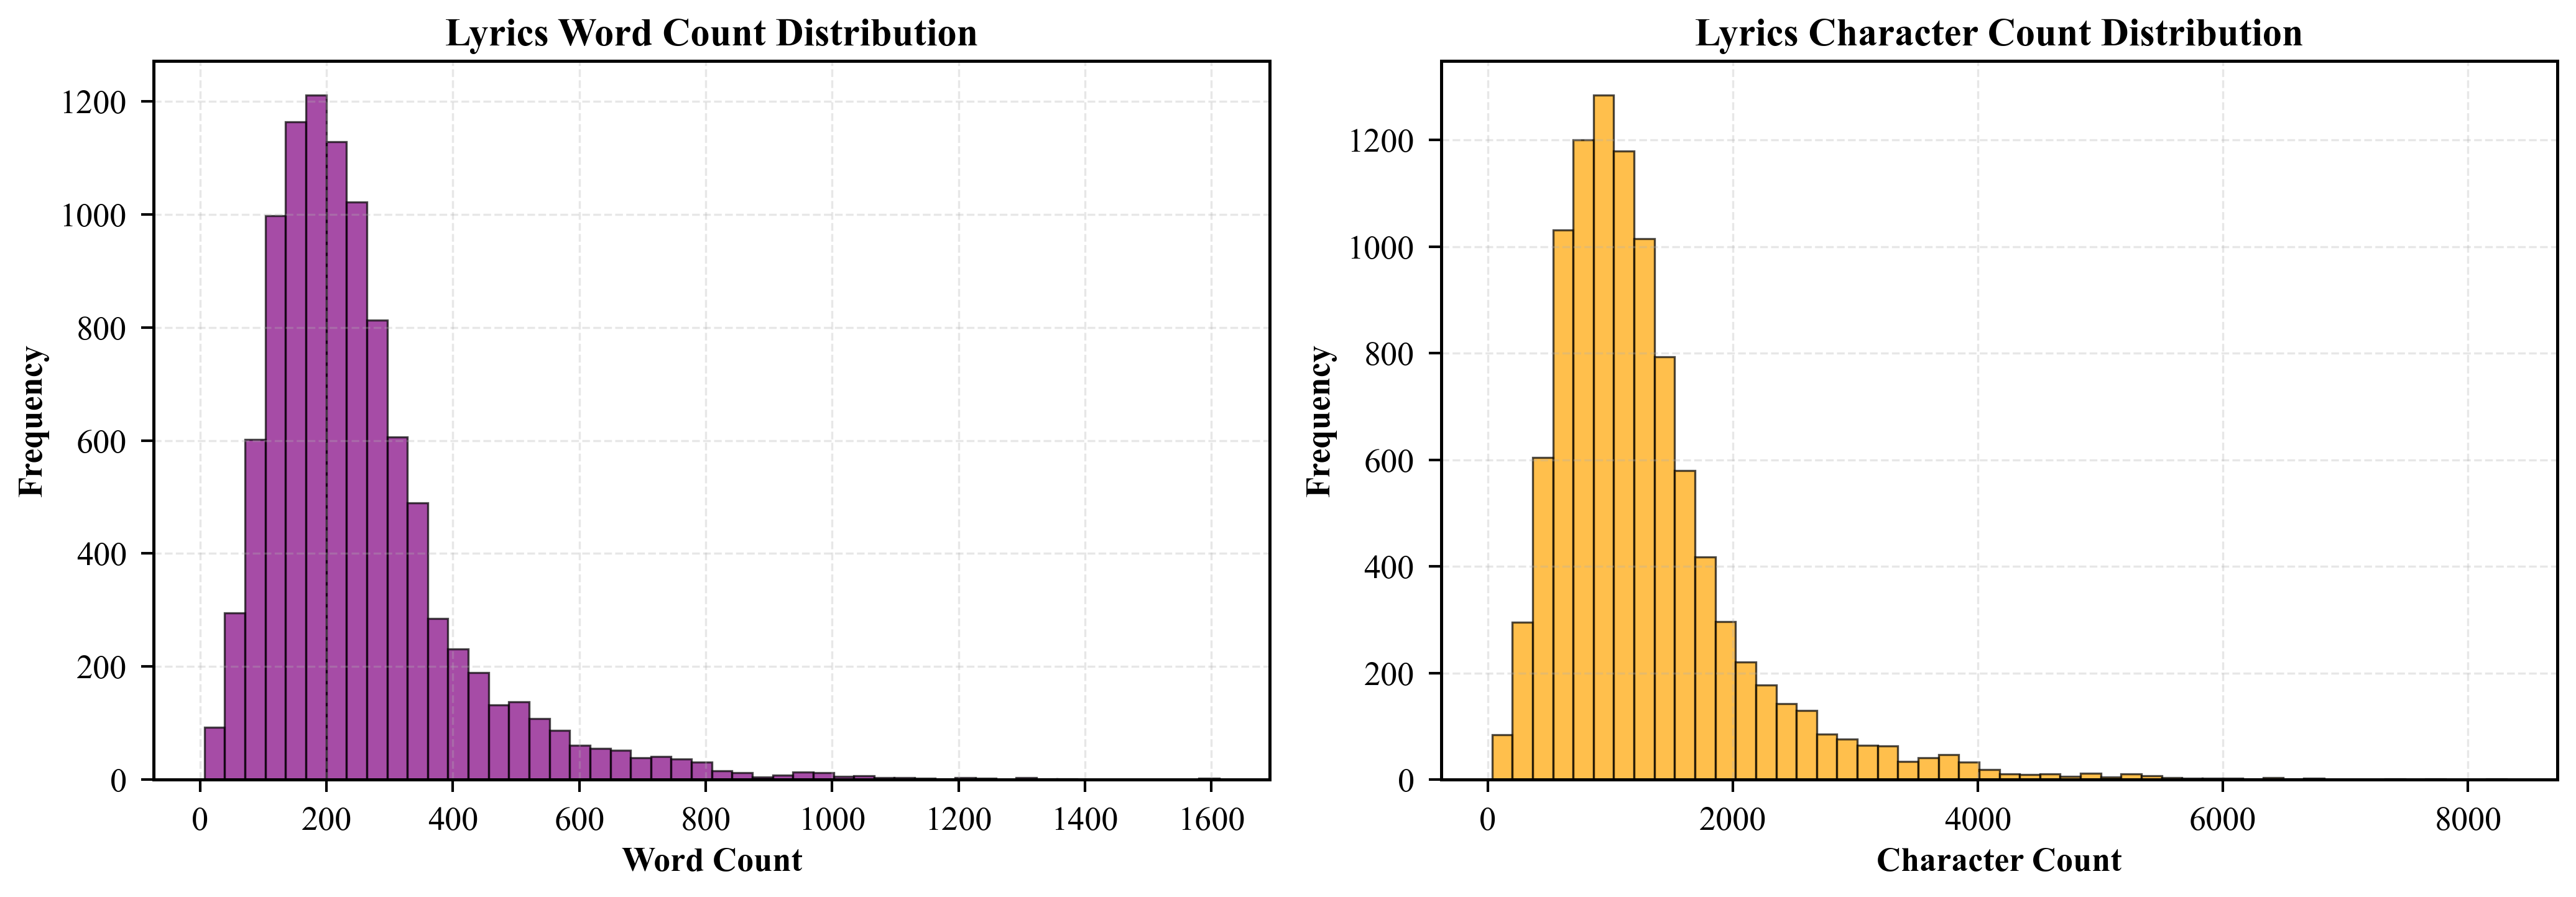

In [23]:
# Lyrics length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_with_lyrics['word_count'], bins=50, edgecolor='black', color='purple', alpha=0.7)
axes[0].set_xlabel('Word Count', fontsize=13)
axes[0].set_ylabel('Frequency', fontsize=13)
axes[0].set_title('Lyrics Word Count Distribution', fontsize=15, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].hist(df_with_lyrics['char_count'], bins=50, edgecolor='black', color='orange', alpha=0.7)
axes[1].set_xlabel('Character Count', fontsize=13)
axes[1].set_ylabel('Frequency', fontsize=13)
axes[1].set_title('Lyrics Character Count Distribution', fontsize=15, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Artist Analysis

Total unique artists: 95,121

Top 20 artists by song count:
artists
["Grateful Dead"]               1500
["Elvis Presley"]               1455
["Aretha Franklin"]             1112
["Bob Dylan"]                    978
["Johnny Cash"]                  764
["Fleetwood Mac"]                727
["The Beatles"]                  723
["Dolly Parton"]                 697
["The Beach Boys"]               675
["Willie Nelson"]                630
["Bob Marley & The Wailers"]     624
["Glee Cast"]                    619
["Frank Sinatra"]                600
["Tori Amos"]                    582
["Dean Martin"]                  547
["Barry Manilow"]                534
["The Rolling Stones"]           534
["Emmylou Harris"]               531
["The Fall"]                     524
["Guided By Voices"]             520
Name: count, dtype: int64


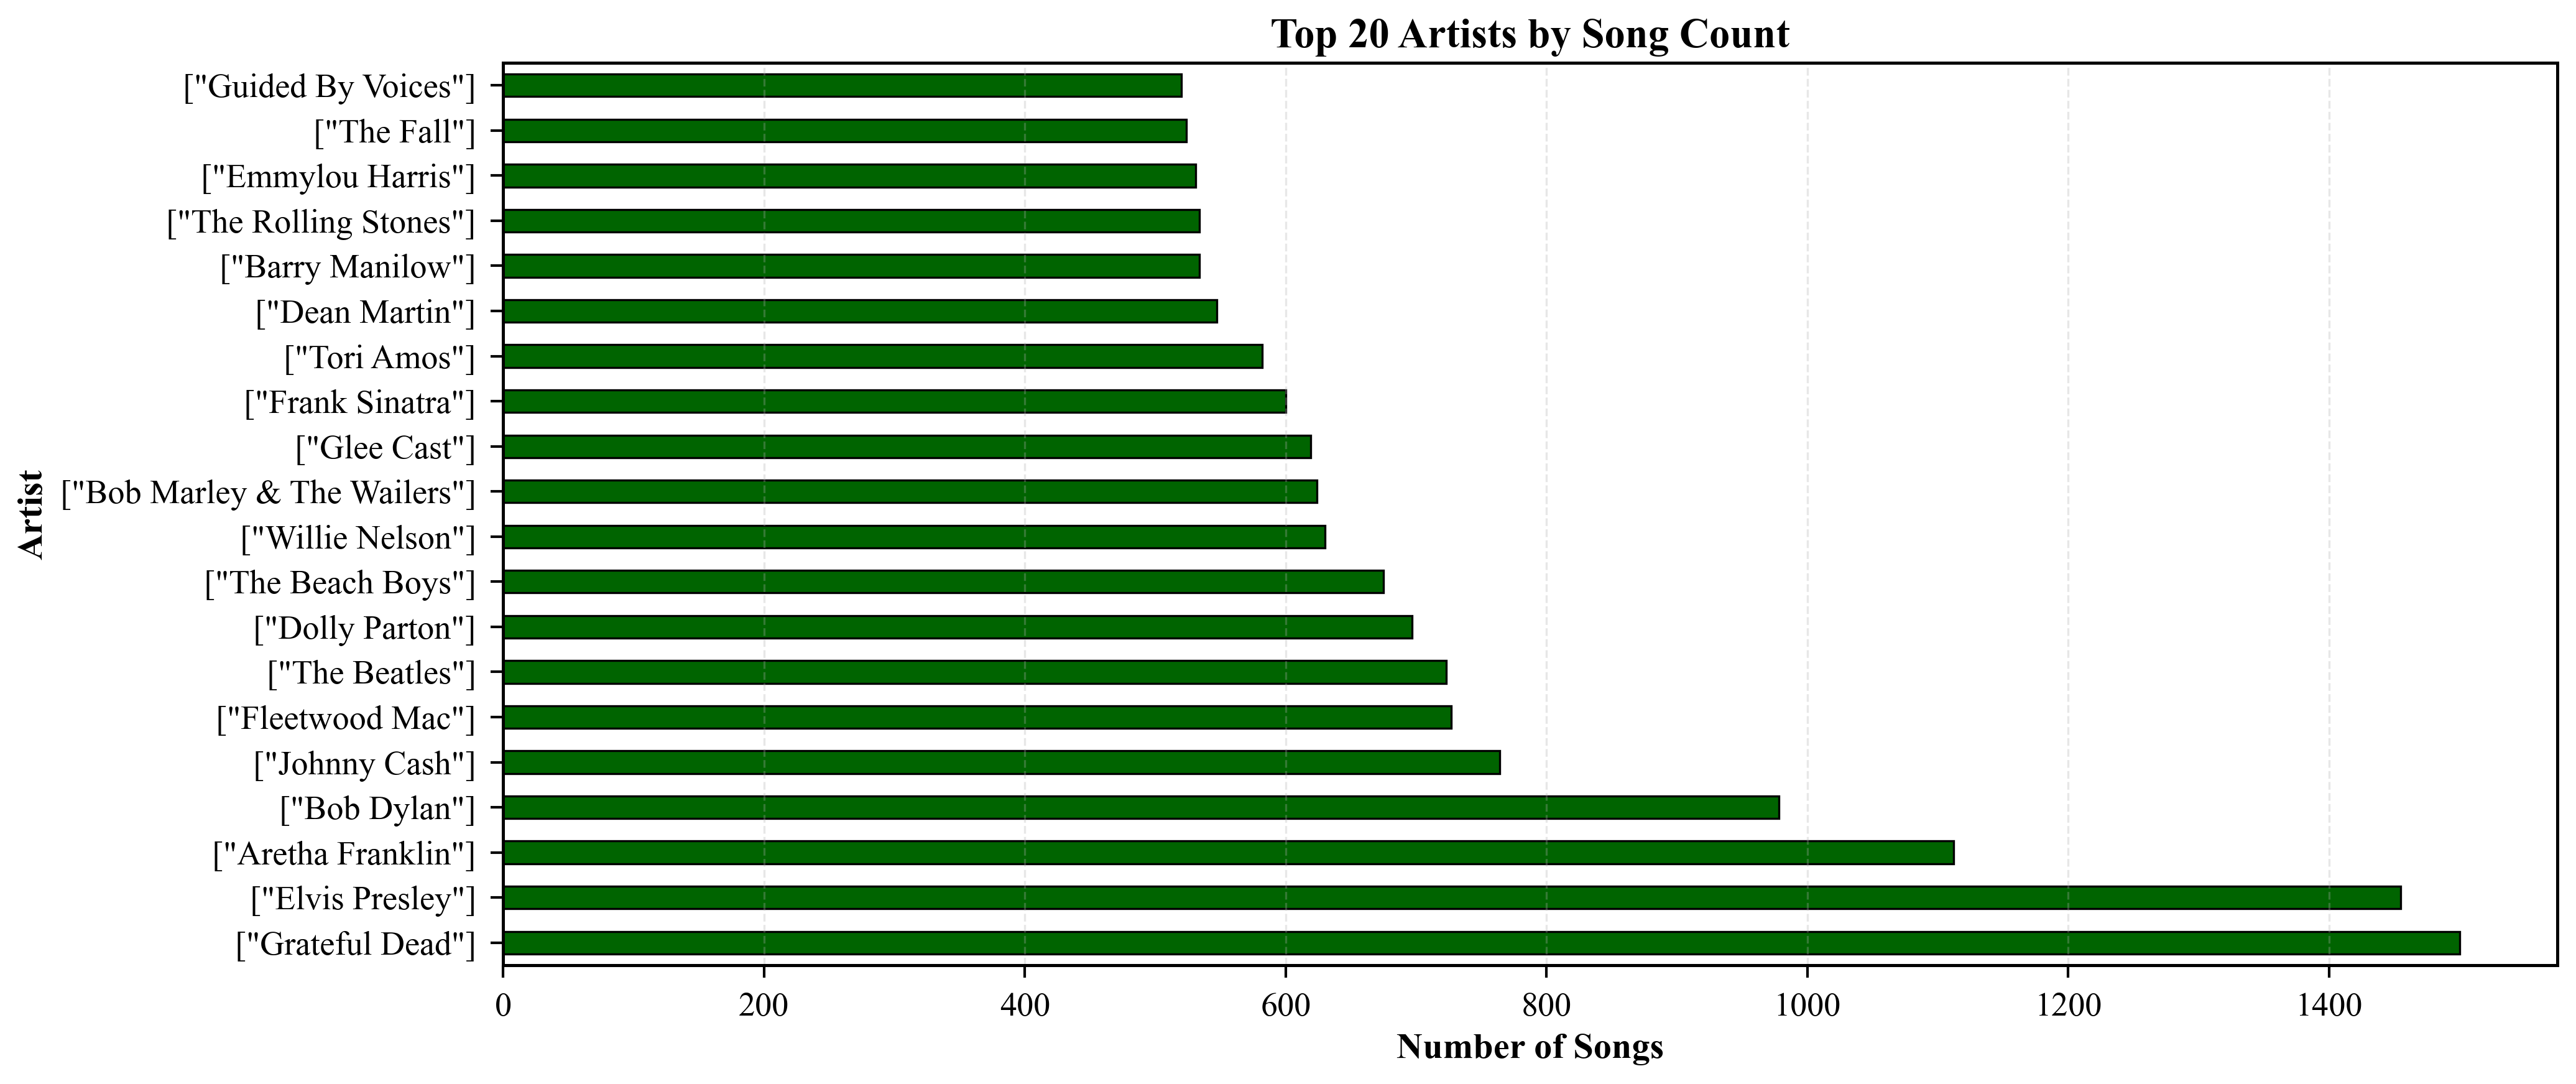


Artist Distribution:
  Artists with 1 song: 58,515
  Artists with 2-5 songs: 22,203
  Artists with 6-10 songs: 5,025
  Artists with >10 songs: 9,378


In [24]:
# Artist distribution
artist_counts = df['artists'].value_counts()

print(f"Total unique artists: {len(artist_counts):,}")
print(f"\nTop 20 artists by song count:")
print(artist_counts.head(20))

# Visualize
plt.figure(figsize=(14, 6))
artist_counts.head(20).plot(kind='barh', color='darkgreen', edgecolor='black')
plt.title('Top 20 Artists by Song Count', fontsize=16, fontweight='bold')
plt.xlabel('Number of Songs', fontsize=14)
plt.ylabel('Artist', fontsize=14)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Artist distribution stats
print(f"\nArtist Distribution:")
print(f"  Artists with 1 song: {(artist_counts == 1).sum():,}")
print(f"  Artists with 2-5 songs: {((artist_counts >= 2) & (artist_counts <= 5)).sum():,}")
print(f"  Artists with 6-10 songs: {((artist_counts >= 6) & (artist_counts <= 10)).sum():,}")
print(f"  Artists with >10 songs: {(artist_counts > 10).sum():,}")

## 10. Artist Features Analysis
### New features for Experiment 2: artist followers and popularity

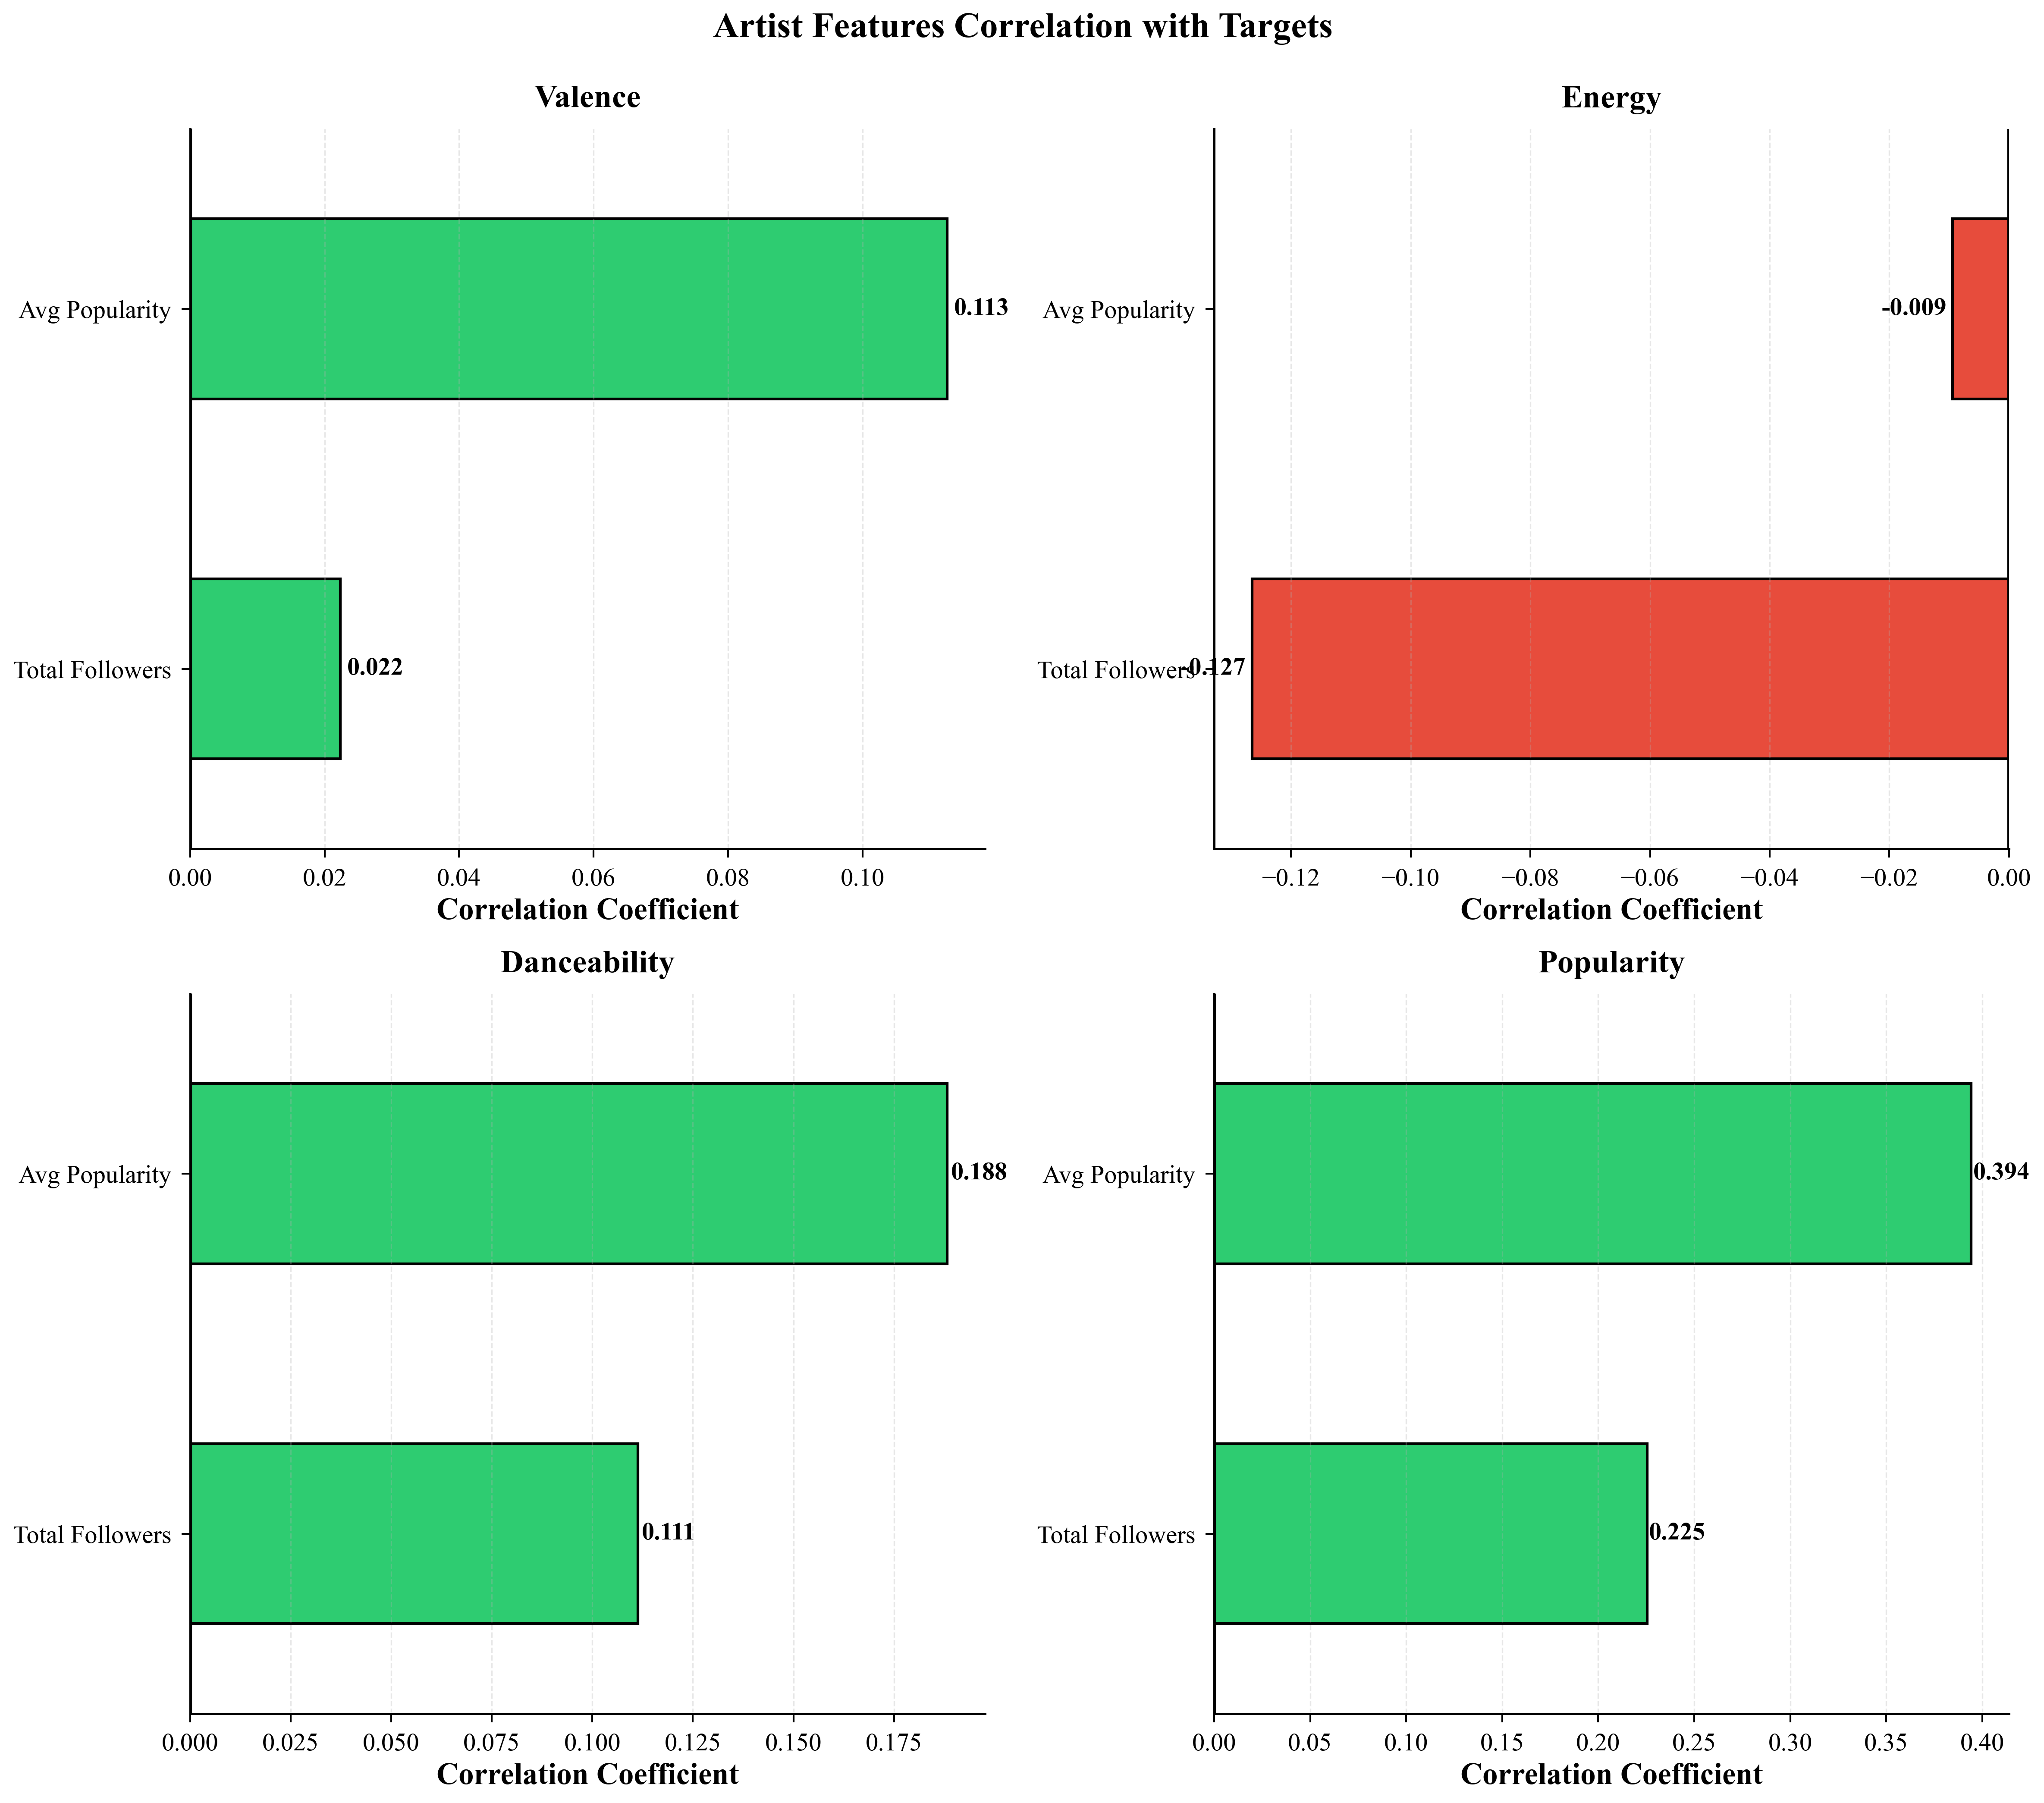


Artist Features Correlation with Targets:

VALENCE:
  total_artist_followers:   r = 0.0224
  avg_artist_popularity:    r = 0.1126

ENERGY:
  total_artist_followers:   r = -0.0094
  avg_artist_popularity:    r = -0.1265

DANCEABILITY:
  total_artist_followers:   r = 0.1113
  avg_artist_popularity:    r = 0.1882

POPULARITY:
  total_artist_followers:   r = 0.2255
  avg_artist_popularity:    r = 0.3942


In [32]:
# Artist features correlation with targets
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Artist Features Correlation with Targets', fontsize=20, fontweight='bold', y=0.995)

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]
    
    # Get correlations with artist features (use raw values, no log)
    corr_data = df[['total_artist_followers', 'avg_artist_popularity', target]].dropna()
    artist_corr = corr_data.corr()[target].drop(target).sort_values(ascending=True)
    
    # Color coding
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in artist_corr.values]
    
    # Horizontal bar plot
    bars = artist_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('Correlation Coefficient', fontsize=17, fontweight='bold')
    ax.set_title(f'{target.capitalize()}', fontsize=18, fontweight='bold', pad=12)
    ax.axvline(0, color='black', linewidth=2)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticklabels(['Total Followers', 'Avg Popularity'], fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    
    # Add value labels
    for i, value in enumerate(artist_corr.values):
        x_pos = value + (0.01 if value > 0 else -0.01)
        ha = 'left' if value > 0 else 'right'
        ax.text(x_pos, i, f'{value:.3f}', va='center', ha=ha, 
                fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/eda/artist_features_target_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("Artist Features Correlation with Targets:")
print("="*80)
for target in target_vars:
    corr_data = df[['total_artist_followers', 'avg_artist_popularity', target]].dropna()
    artist_corr = corr_data.corr()[target].drop(target)
    print(f"\n{target.upper()}:")
    print(f"  total_artist_followers:   r = {artist_corr['total_artist_followers']:.4f}")
    print(f"  avg_artist_popularity:    r = {artist_corr['avg_artist_popularity']:.4f}")
print("="*80)

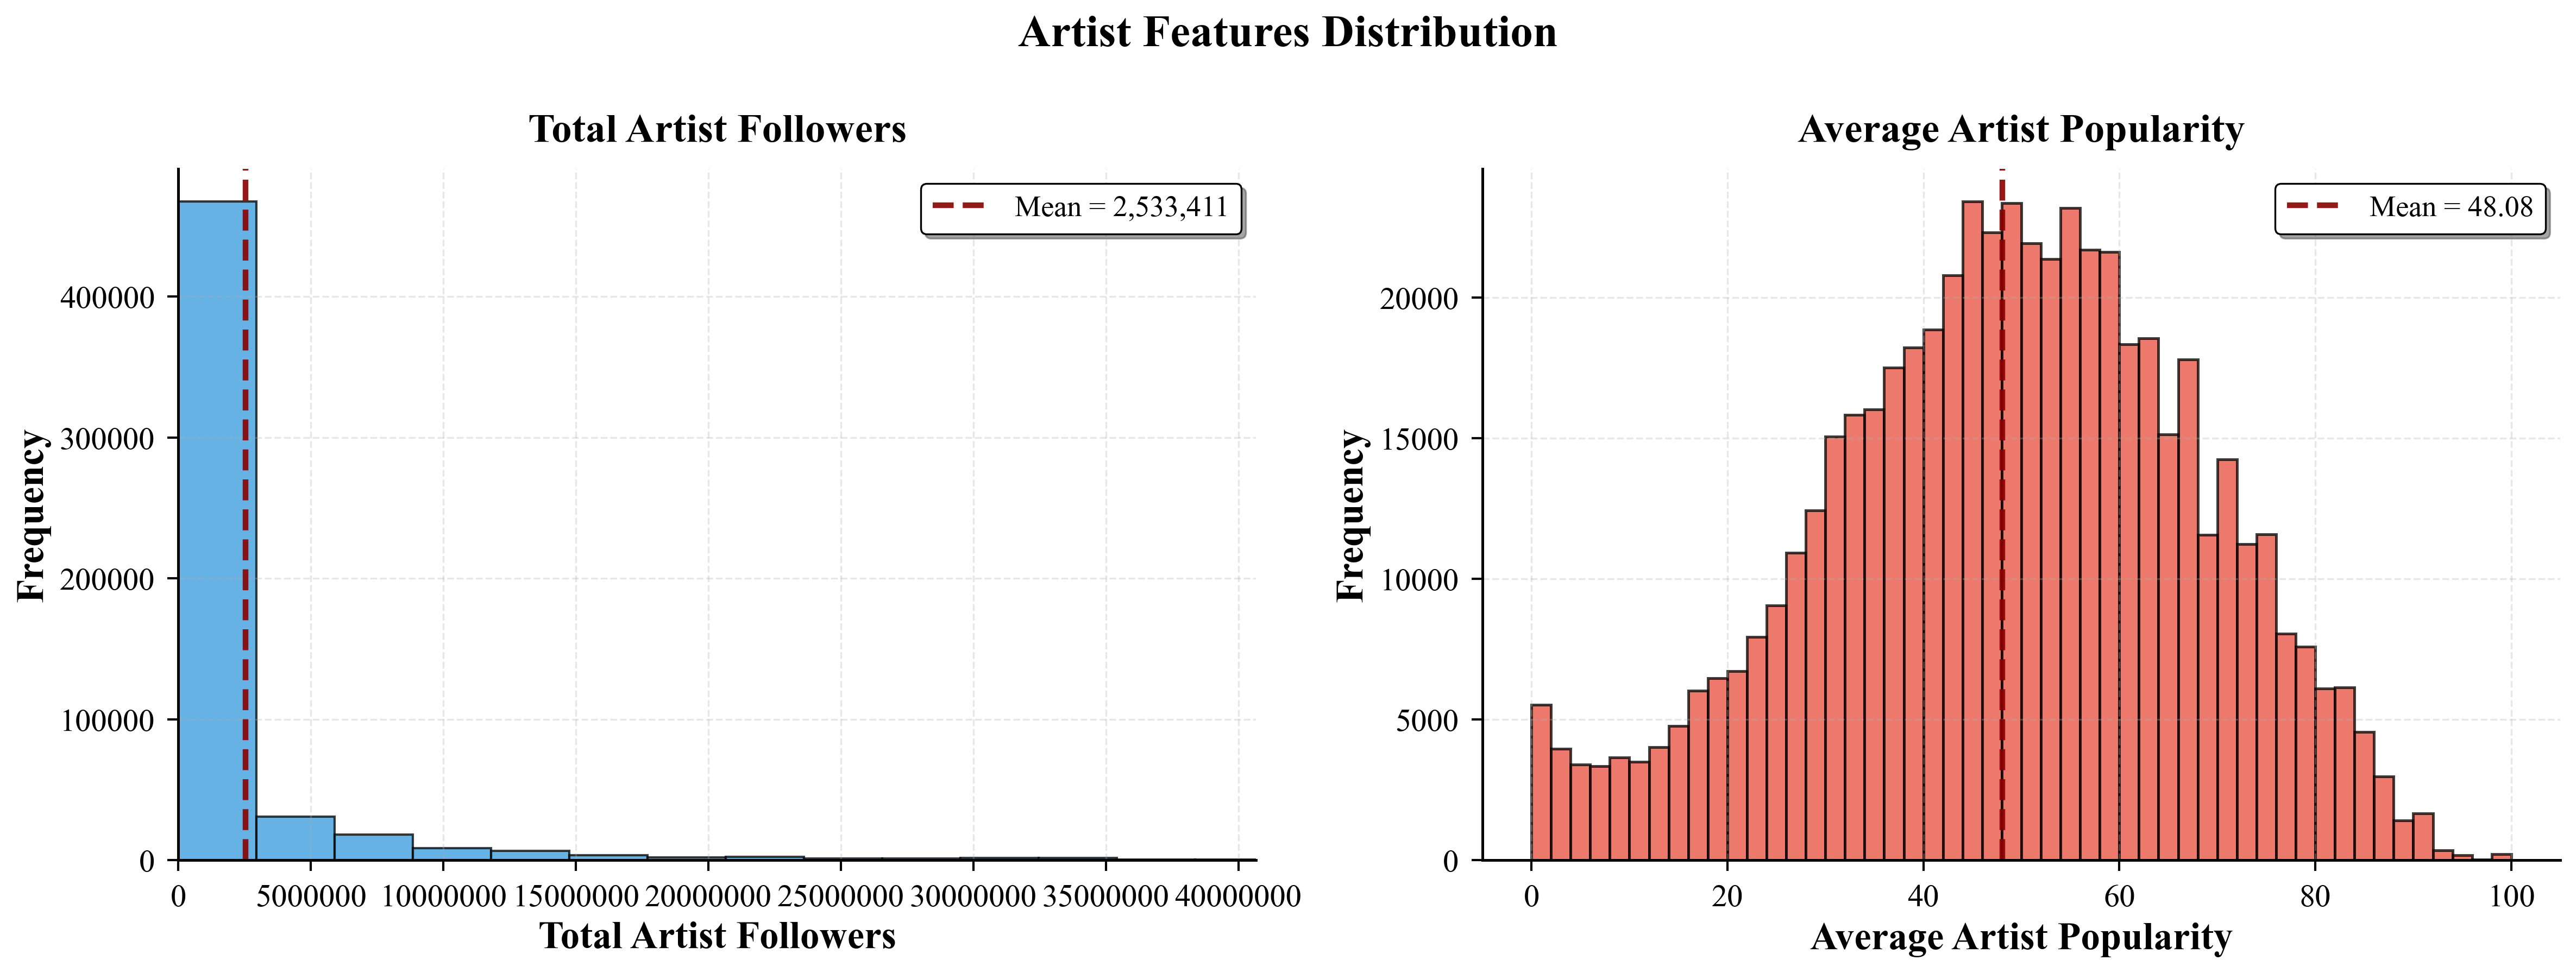


Artist Features Statistics:
Total Artist Followers:
 Mean: 2,533,411
 Median: 269,383
 Max: 295,181,876

Average Artist Popularity:
 Mean: 48.08
 Median: 49.00
 Max: 100.00


In [38]:
# Artist features distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Artist Features Distribution', fontsize=20, fontweight='bold', y=0.995)

# Total Artist Followers (improved visualization)
ax = axes[0]
followers = df['total_artist_followers'].dropna()

# Use more bins and linear scale for better distribution visibility
ax.hist(followers, bins=100, edgecolor='black', alpha=0.75,
        color='#3498db', linewidth=1.0)  # Thinner edges like the other plot

mean_val = followers.mean()
ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2.5,
           label=f'Mean = {mean_val:,.0f}', alpha=0.9)

ax.set_xlabel('Total Artist Followers', fontsize=17, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=17, fontweight='bold')
ax.set_title('Total Artist Followers', fontsize=18, fontweight='bold', pad=12)
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=13)  # Moved to upper right since most data is on the left
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=14)
ax.set_xlim(left=0)
ax.set_xlim(right=followers.quantile(0.99))
# Optional: Use scientific notation or format large numbers on x-axis for clarity
ax.ticklabel_format(style='plain', axis='x')  # Or use 'sci' if preferred

# Average Artist Popularity (unchanged - already good)
ax = axes[1]
popularity = df['avg_artist_popularity'].dropna()
ax.hist(popularity, bins=50, edgecolor='black', alpha=0.75,
        color='#e74c3c', linewidth=1.2)
mean_val = popularity.mean()
ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2.5,
           label=f'Mean = {mean_val:.2f}', alpha=0.9)
ax.set_xlabel('Average Artist Popularity', fontsize=17, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=17, fontweight='bold')
ax.set_title('Average Artist Popularity', fontsize=18, fontweight='bold', pad=12)
ax.legend(loc='best', frameon=True, shadow=True, fontsize=13)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('../results/figures/eda/artist_features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("Artist Features Statistics:")
print("="*80)
print(f"Total Artist Followers:")
print(f" Mean: {df['total_artist_followers'].mean():,.0f}")
print(f" Median: {df['total_artist_followers'].median():,.0f}")
print(f" Max: {df['total_artist_followers'].max():,.0f}")
print(f"\nAverage Artist Popularity:")
print(f" Mean: {df['avg_artist_popularity'].mean():.2f}")
print(f" Median: {df['avg_artist_popularity'].median():.2f}")
print(f" Max: {df['avg_artist_popularity'].max():.2f}")
print("="*80)

## 10. Artist Features Analysis (Experiment 2)
### Analyzing artist fame metrics: followers and popularity

In [27]:
print("="*80)
print("KEY INSIGHTS")
print("="*80)

print("\n📊 Dataset:")
print(f"  - Songs: {len(df):,}")
print(f"  - Artists: {df['artists'].nunique():,}")
print(f"  - Genres: {df['genre'].nunique():,}")
print(f"  - Years: {df['year'].min()} - {df['year'].max()}")
print(f"  - With lyrics: {has_lyrics.sum():,} ({has_lyrics.sum()/len(df)*100:.1f}%)")

print("\n🎯 Target Variables:")
for target in target_vars:
    print(f"  - {target.capitalize():15s}: Mean={df[target].mean():.3f}, Range=[{df[target].min():.3f}, {df[target].max():.3f}]")

print("\n✨ Artist Features:")
print(f"  - Followers:  Mean={df['total_artist_followers'].mean():,.0f}, Median={df['total_artist_followers'].median():,.0f}")
print(f"  - Popularity: Mean={df['avg_artist_popularity'].mean():.2f}, Median={df['avg_artist_popularity'].median():.2f}")

print("\n🔗 Top Correlations:")
for target in target_vars:
    target_corr = df[audio_features + [target]].corr()[target].drop(target).abs().sort_values(ascending=False)
    top_feature = target_corr.index[0]
    top_value = target_corr.iloc[0]
    print(f"  - {target.capitalize():15s}: {top_feature} (r={top_value:.3f})")

print("\n🎤 Artist Features Impact:")
for target in target_vars:
    corr_data = df[['total_artist_followers', 'avg_artist_popularity', target]].dropna()
    artist_corr = corr_data.corr()[target].drop(target)
    max_feature = artist_corr.abs().idxmax()
    max_value = artist_corr[max_feature]
    feature_name = 'Followers' if 'followers' in max_feature else 'Popularity'
    print(f"  - {target.capitalize():15s}: {feature_name} (r={max_value:.3f})")

print("\n" + "="*80)
print("Next: Train models with artist features (Experiment 2)")
print("="*80)

KEY INSIGHTS

📊 Dataset:
  - Songs: 550,622
  - Artists: 95,121
  - Genres: 10
  - Years: 1900 - 2025
  - With lyrics: 549,546 (99.8%)

🎯 Target Variables:
  - Valence        : Mean=0.465, Range=[0.000, 0.998]
  - Energy         : Mean=0.671, Range=[0.000, 1.000]
  - Danceability   : Mean=0.527, Range=[0.045, 0.988]
  - Popularity     : Mean=17.576, Range=[0.000, 98.000]

✨ Artist Features:
  - Followers:  Mean=2,533,411, Median=269,383
  - Popularity: Mean=48.08, Median=49.00

🔗 Top Correlations:
  - Valence        : duration_ms (r=0.206)
  - Energy         : loudness (r=0.777)
  - Danceability   : instrumentalness (r=0.191)
  - Popularity     : instrumentalness (r=0.088)

🎤 Artist Features Impact:
  - Valence        : Popularity (r=0.113)
  - Energy         : Popularity (r=-0.127)
  - Danceability   : Popularity (r=0.188)
  - Popularity     : Popularity (r=0.394)

Next: Train models with artist features (Experiment 2)


## 📝 Observations to Document

**Fill this in after running the notebook:**

1. **Target Distribution:**
   - Are targets balanced or skewed?
   - Any unusual patterns?

2. **Feature Correlations:**
   - Which features correlate strongly with each target?
   - Any multicollinearity issues?

3. **Genre Patterns:**
   - Do certain genres have distinct target values?
   - Genre imbalance?

4. **Temporal Trends:**
   - How have music characteristics changed over time?
   - Any era-specific patterns?

5. **Data Quality:**
   - Any remaining issues?
   - Features that need special handling?